# Phase 3 — Hybrid Prophet + XGBoost Revenue Forecasting
**Target:** `Daily_Revenue` | **Horizon:** 548 ngày | **Method:** Prophet (trend) + XGBoost (residual)

In [2]:
# Cell cài đặt toàn bộ thư viện cho Workflow 1, 2 và 3
# %pip sẽ tự động xác định và cài đặt vào môi trường của Kernel đang chạy
#%pip install optuna
# %pip install --upgrade plotly
# %pip install shap notebook
# %pip install pandas numpy matplotlib seaborn scikit-learn prophet xgboost lightgbm shap optuna

In [3]:
# ── 0. SETUP ──────────────────────────────────────────────────────────────────
import os
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import shap
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "font.family": "sans-serif"
})

DATA   = "csv/ml_ready/"
RANDOM = 42

def competition_metrics(y_true, y_pred, label=""):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    wape = np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()
    print(f"  {label:<16} | MAE: {mae:>10,.0f} | RMSE: {rmse:>10,.0f} | R\u00b2: {r2:>7.4f} | WAPE: {wape:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "WAPE": wape}

print("Phase 3 Initialization Complete. Libraries loaded.")


Phase 3 Initialization Complete. Libraries loaded.


In [4]:
# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA + RECONCILIATION vs GROUND TRUTH
# ══════════════════════════════════════════════════════════════════
train = pd.read_csv(DATA + "ts_train.csv")
val   = pd.read_csv(DATA + "ts_val.csv")

# ── Normalize datetime: loại bỏ giờ/phút/giây gây mismatch ───────
for df in (train, val):
    df["order_date"] = pd.to_datetime(df["order_date"]).dt.normalize()
    df.sort_values("order_date", inplace=True)
    df.reset_index(drop=True, inplace=True)

assert val.order_date.min() > train.order_date.max(), "LEAKAGE: Val overlaps Train!"

# ── RECONCILIATION: so sánh internal data vs ground truth ─────────
GT_PATH = "csv/sales.csv"
MISMATCH_THRESHOLD = 1_000_000   # VND — ngưỡng cảnh báo

if os.path.exists(GT_PATH):
    gt = pd.read_csv(GT_PATH, parse_dates=["Date"])
    gt["Date"] = pd.to_datetime(gt["Date"]).dt.normalize()
    gt = gt.rename(columns={"Revenue": "GT_Revenue"})

    # Gộp internal vs GT theo ngày
    internal = pd.concat([train, val])[["order_date","Daily_Revenue"]].copy()
    internal = internal.rename(columns={"order_date":"Date"})

    recon = internal.merge(gt[["Date","GT_Revenue"]], on="Date", how="inner")
    recon["delta"] = (recon["Daily_Revenue"] - recon["GT_Revenue"]).abs()

    total_delta    = recon["delta"].sum()
    bad_days       = recon[recon["delta"] > MISMATCH_THRESHOLD].sort_values("delta", ascending=False)

    print(f"Reconciliation: {len(recon)} overlapping days")
    print(f"  Total absolute mismatch : {total_delta:>15,.0f} VND")
    print(f"  Days > {MISMATCH_THRESHOLD/1e6:.0f}M mismatch  : {len(bad_days)}")

    if len(bad_days) > 0:
        print("\n  Top 10 mismatch days:")
        print(bad_days[["Date","Daily_Revenue","GT_Revenue","delta"]].head(10)
              .to_string(index=False))

    # ── FIX: nếu GT tồn tại → dùng GT_Revenue làm ground truth cho train/val
    # Điều này đảm bảo residual = GT_Revenue - yhat_prophet (không bị lệch do pipeline)
    gt_map = gt.set_index("Date")["GT_Revenue"]
    n_replaced = 0
    for df in (train, val):
        matched = df["order_date"].map(gt_map)
        n_replaced += matched.notna().sum()
        df["Daily_Revenue"] = np.where(matched.notna(), matched, df["Daily_Revenue"])
        df["source"] = np.where(matched.notna(), "GT", "internal")
    print(f"\n  Replaced {n_replaced} rows with GT values in train/val → residual now GT-aligned")
else:
    print(f"[WARN] Ground truth not found at {GT_PATH} — using internal data only")
    for df in (train, val):
        df["source"] = "internal"

# ── Cyclical time features ─────────────────────────────────────────
def engineer_time_features(df):
    d = df["order_date"].dt
    df["Year"]         = d.year
    df["Month"]        = d.month
    df["Quarter"]      = d.quarter
    df["Week_of_Year"] = d.isocalendar().week.astype(int)
    df["Day_of_Month"] = d.day
    df["Day_of_Week"]  = d.dayofweek
    df["Day_of_Year"]  = d.dayofyear
    df["Is_Weekend"]      = (d.dayofweek >= 5).astype(int)
    df["Is_Month_Start"]  = d.is_month_start.astype(int)
    df["Is_Month_End"]    = d.is_month_end.astype(int)
    df["Is_Quarter_End"]  = d.is_quarter_end.astype(int)
    df["Is_Year_End"]     = ((d.month == 12) & (d.day == 31)).astype(int)
    df["sin_dow"]   = np.sin(2 * np.pi * df["Day_of_Week"] / 7)
    df["cos_dow"]   = np.cos(2 * np.pi * df["Day_of_Week"] / 7)
    df["sin_doy"]   = np.sin(2 * np.pi * df["Day_of_Year"] / 365.25)
    df["cos_doy"]   = np.cos(2 * np.pi * df["Day_of_Year"] / 365.25)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df

train, val = engineer_time_features(train), engineer_time_features(val)
print(f"\nTrain: {train.order_date.min().date()} → {train.order_date.max().date()} ({len(train)} days)")
print(f"Val  : {val.order_date.min().date()} → {val.order_date.max().date()} ({len(val)} days)")


Reconciliation: 3284 overlapping days
  Total absolute mismatch :   1,930,813,285 VND
  Days > 1M mismatch  : 459

  Top 10 mismatch days:
      Date  Daily_Revenue  GT_Revenue      delta
2017-03-30    13777286.05 17516038.82 3738752.77
2017-06-29    10993569.71 14575854.67 3582284.96
2016-06-29     9905809.05 13343751.12 3437942.07
2015-03-31    11609120.04 14813965.34 3204845.30
2017-03-31    13366663.41 16556662.03 3189998.62
2018-06-29     9361044.95 12484085.14 3123040.19
2017-04-02    11701902.96 14750037.65 3048134.69
2017-04-01    12824644.78 15808755.61 2984110.83
2016-06-30     8881170.14 11824115.33 2942945.19
2017-06-28     8214753.28 11067229.74 2852476.46

  Replaced 3284 rows with GT values in train/val → residual now GT-aligned

Train: 2013-07-04 → 2021-12-31 (3103 days)
Val  : 2022-01-01 → 2022-06-30 (181 days)


In [5]:
# ══════════════════════════════════════════════════════════════════
# 2. STRICT ANTI-LEAKAGE MOMENTUM FEATURES & NAN HANDLING
# ══════════════════════════════════════════════════════════════════
print("Engineering Momentum Features with Strict Leakage Prevention...")

# 1. Gộp Train và Val theo chuẩn Chronological để Val có thể nhìn thấy dữ liệu cuối của Train
all_dates = pd.concat([train, val]).sort_values("order_date").reset_index(drop=True)
rev_series = all_dates["Daily_Revenue"]

# CRITICAL: Chỉ lấy Median của tập Train để điền NaN (Không để rò rỉ Median của Val sang Train)
train_median = train["Daily_Revenue"].median()

# 2. Tính toán Lags (Đảm bảo ngày T chỉ nhìn thấy T-Lag)
for lag in [1, 2, 3, 7, 14, 30, 90, 364]:
    # Shift, sau đó điền Median cho các ngày NaN đầu tiên, rồi ép thẳng về Float
    all_dates[f"Lag_{lag}D"] = rev_series.shift(lag).fillna(train_median).astype(float)

# 3. Tính toán Rolling & Volatility (BẮT BUỘC shift(1) trước khi gọi rolling)
for window in [7, 14, 30]:
    rolled = rev_series.shift(1).rolling(window, min_periods=1)
    
    all_dates[f"Roll_Mean_{window}D"] = rolled.mean().fillna(train_median).astype(float)
    all_dates[f"Roll_Std_{window}D"]  = rolled.std().fillna(0).astype(float) # Độ lệch chuẩn NaN -> 0
    all_dates[f"Roll_Max_{window}D"]  = rolled.max().fillna(train_median).astype(float)
    all_dates[f"Roll_Min_{window}D"]  = rolled.min().fillna(train_median).astype(float)

# 4. Tính toán EMA (BẮT BUỘC shift(1) trước khi gọi ewm)
for span in [7, 14, 30]:
    ema = rev_series.shift(1).ewm(span=span, adjust=False).mean()
    all_dates[f"EMA_{span}D"] = ema.fillna(train_median).astype(float)

# 5. Tách trả lại tập Train và Val nguyên vẹn
train_end = train["order_date"].max()
train = all_dates[all_dates["order_date"] <= train_end].copy()
val   = all_dates[all_dates["order_date"] > train_end].copy()

# Day-of-Week × Mega Sale interaction
all_dates["DoW_x_MegaSale"] = all_dates["Day_of_Week"] * all_dates.get("Is_Mega_Sale", 0)
# Month × Weekend interaction  
all_dates["Month_x_Weekend"] = all_dates["Month"] * all_dates["Is_Weekend"]

# Định nghĩa danh sách các Feature nạp vào XGBoost
FEATS = [
    "Day_of_Week", "Month", "Quarter", "Year", "Day_of_Year", "Week_of_Year", "Day_of_Month",
    "Is_Weekend", "Is_Month_Start", "Is_Month_End", "Is_Quarter_End", "Is_Year_End",
    "sin_dow", "cos_dow", "sin_doy", "cos_doy", "sin_month", "cos_month",
    "Lag_1D", "Lag_2D", "Lag_3D", "Lag_7D", "Lag_14D", "Lag_30D", "Lag_90D", "Lag_364D",
    "Roll_Mean_7D", "Roll_Mean_14D", "Roll_Mean_30D",
    "Roll_Std_7D", "Roll_Std_14D", "Roll_Std_30D",
    "Roll_Max_7D", "Roll_Max_14D", "Roll_Max_30D",
    "Roll_Min_7D", "Roll_Min_14D", "Roll_Min_30D",
    "EMA_7D", "EMA_14D", "EMA_30D"
]

OPTIONAL_FEATS = ["Is_Public_Holiday", "Is_Mega_Sale", "N_Active_Promos", "Total_Sessions", "Avg_Bounce_Rate"]
FEATS += [f for f in OPTIONAL_FEATS if f in train.columns]

train[FEATS] = train[FEATS].fillna(0).astype(float)
val[FEATS]   = val[FEATS].fillna(0).astype(float)

print(f"✅ Extracted {len(FEATS)} strictly out-of-sample features.")

Engineering Momentum Features with Strict Leakage Prevention...
✅ Extracted 46 strictly out-of-sample features.


In [6]:
# ══════════════════════════════════════════════════════════════════
# 3. PROPHET: ADVANCED HOLIDAY INJECTION & TREND MODELING
# ══════════════════════════════════════════════════════════════════
print("Training Prophet Baseline Model (Trend & Seasonality)...")
years = list(range(2012, 2026))
pub_hols, mega_sales = [], []

for y in years:
    # 1. Các ngày lễ truyền thống (Public Holidays)
    pub_hols += [
        {"holiday":"new_year",      "ds": pd.Timestamp(f"{y}-01-01"), "lower_window":-1, "upper_window":1},
        {"holiday":"liberation_day","ds": pd.Timestamp(f"{y}-04-30"), "lower_window":-1, "upper_window":0},
        {"holiday":"labour_day",    "ds": pd.Timestamp(f"{y}-05-01"), "lower_window":0,  "upper_window":1},
        {"holiday":"national_day",  "ds": pd.Timestamp(f"{y}-09-02"), "lower_window":-1, "upper_window":1},
    ]
    # 2. Các ngày hội mua sắm khổng lồ cuối năm (Year-end Mega Sales)
    mega_sales += [
        {"holiday":"double_11",   "ds": pd.Timestamp(f"{y}-11-11"), "lower_window":-2, "upper_window":1},
        {"holiday":"double_12",   "ds": pd.Timestamp(f"{y}-12-12"), "lower_window":-2, "upper_window":1},
        {"holiday":"year_end",    "ds": pd.Timestamp(f"{y}-12-31"), "lower_window":-3, "upper_window":0},
    ]
    # 3. NEW: Bổ sung Siêu sale đôi giữa năm (Mid-year Double Days)
    # Đây là insight kinh doanh xuất sắc giúp bắt đỉnh doanh thu hàng tháng
    for month in [6, 7, 8, 9, 10]:
        mega_sales.append(
            {"holiday": f"double_{month}", "ds": pd.Timestamp(f"{y}-{month:02d}-{month:02d}"), "lower_window": -1, "upper_window": 1}
        )

# 4. Ngày lễ Tết Nguyên Đán (Dịch chuyển theo từng năm)
# Đã tinh chỉnh: -7 ngày (Đổ xô sắm Tết) và +3 ngày (Giảm mạnh do nghỉ bán)
tet_dates = {
    2012:"2012-01-23", 2013:"2013-02-10", 2014:"2014-01-31", 2015:"2015-02-19", 2016:"2016-02-08",
    2017:"2017-01-28", 2018:"2018-02-16", 2019:"2019-02-05", 2020:"2020-01-25", 2021:"2021-02-12",
    2022:"2022-02-01", 2023:"2023-01-22", 2024:"2024-02-10", 2025:"2025-01-29"
}
for y, dt in tet_dates.items():
    mega_sales.append({"holiday":"tet", "ds":pd.Timestamp(dt), "lower_window":-7, "upper_window":3})

holidays_df = pd.DataFrame(pub_hols + mega_sales)

#Fix Make_prophet function (could be tighter)
def make_prophet():
    m = Prophet(
        yearly_seasonality=15,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05,    # ← REDUCE from 0.1 (less overfit to trend breaks)
        seasonality_prior_scale=10.0,    # ← REDUCE from 15 (prevent wild seasonal swings)
        holidays_prior_scale=20.0,       # ← INCREASE (holidays are real, let Prophet trust them)
        holidays=holidays_df,
        changepoint_range=0.9,           # ← ADD: allow changepoints closer to end of data
    )
    m.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    m.add_seasonality(name="quarterly", period=91.25, fourier_order=3)  # ← ADD
    return m


# A. Evaluate locally (Train only)
prophet_df_tr = train[["order_date","Daily_Revenue"]].rename(columns={"order_date":"ds","Daily_Revenue":"y"})
m_eval = make_prophet()
m_eval.fit(prophet_df_tr)

def get_prophet_forecast(m, dates):
    fc = m.predict(pd.DataFrame({"ds": pd.to_datetime(dates)}))
    return fc.set_index("ds")["yhat"].values

# Update residuals
for df in [train, val]:
    df["yhat_prophet"] = get_prophet_forecast(m_eval, df.order_date)
    df["residual"] = df["Daily_Revenue"] - df["yhat_prophet"]

print("--- PROPHET BASELINE METRICS ---")
_ = competition_metrics(val.Daily_Revenue, val.yhat_prophet, "Prophet (Val)")

# B. Train FULL model for final Kaggle forecast
# FIX B2: Use GT-aligned train/val (not all_dates which was built before GT replacement)
all_hist_prophet = pd.concat([train, val])[["order_date","Daily_Revenue"]].sort_values("order_date").rename(columns={"order_date":"ds","Daily_Revenue":"y"})
m_full = make_prophet()
m_full.fit(all_hist_prophet)
print("\n Prophet Full Production Model Trained (Including Mid-Year Sales).")

Training Prophet Baseline Model (Trend & Seasonality)...


11:10:33 - cmdstanpy - INFO - Chain [1] start processing
11:10:34 - cmdstanpy - INFO - Chain [1] done processing


--- PROPHET BASELINE METRICS ---
  Prophet (Val)    | MAE:  1,118,859 | RMSE:  1,513,682 | R²:  0.3102 | WAPE: 0.2925


11:10:35 - cmdstanpy - INFO - Chain [1] start processing
11:10:36 - cmdstanpy - INFO - Chain [1] done processing



 Prophet Full Production Model Trained (Including Mid-Year Sales).


In [7]:
# ══════════════════════════════════════════════════════════════════
# 4a. XGBOOST PIPELINE: Scaling → Optuna(WAPE+TSS) → SHAP Pruning
# ══════════════════════════════════════════════════════════════════
import optuna, os
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tr_raw = train[FEATS].fillna(0).values
X_vl_raw = val[FEATS].fillna(0).values

# ── STEP 1: RobustScaler trên residual ────────────────────────────
# Residual Prophet biên độ lớn → scale giúp XGBoost học ổn định hơn
# RobustScaler dùng median/IQR → không bị kéo bởi outlier spike
# CRITICAL: fit ONLY trên train_residual → không leak val/test
res_scaler = RobustScaler()
y_tr_scaled = res_scaler.fit_transform(train[["residual"]]).ravel()
y_vl_scaled = res_scaler.transform(val[["residual"]]).ravel()

# ── STEP 2: Optuna objective = WAPE với TimeSeriesSplit ───────────
# Tại sao WAPE thay MAE?
# MAE phạt đều mọi ngày → model học giỏi ngày thấp nhưng bỏ qua ngày peak.
# WAPE = tổng sai số / tổng doanh thu → phạt nặng hơn khi sai ở ngày revenue cao.
# Leaderboard đánh giá theo WAPE → optimize thẳng metric thi đấu.
#
# Tại sao TimeSeriesSplit thay val cố định?
# Val cố định (Jan-Jun 2022) chỉ test 1 pattern → overfit hyperparams vào mùa đó.
# TSS 5-fold test nhiều khoảng thời gian → params bền vững hơn trên 548 ngày tương lai.

TSS_FOLDS = 5
tss = TimeSeriesSplit(n_splits=TSS_FOLDS)

def wape_metric(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + 1e-9)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int  ("n_estimators",      500,  3000, step=250),
        max_depth         = trial.suggest_int  ("max_depth",         3,    12),
        learning_rate     = trial.suggest_float("learning_rate",     5e-4, 1e-2, log=True),
        subsample         = trial.suggest_float("subsample",         0.6,  1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree",  0.5,  1.0),
        min_child_weight  = trial.suggest_int  ("min_child_weight",  3,    30),
        reg_lambda        = trial.suggest_float("reg_lambda",        1.0,  20.0),
        reg_alpha         = trial.suggest_float("reg_alpha",         0.0,   5.0),
        gamma             = trial.suggest_float("gamma",             0.0,   5.0),
    )
    # TSS cross-val trên SCALED residual — đánh giá bằng WAPE trên ORIGINAL scale
    fold_wapes = []
    for fold_tr_idx, fold_vl_idx in tss.split(X_tr_raw):
        Xf_tr, Xf_vl = X_tr_raw[fold_tr_idx], X_tr_raw[fold_vl_idx]
        yf_tr         = y_tr_scaled[fold_tr_idx]
        # Ground truth fold val ở ORIGINAL scale để tính WAPE có nghĩa
        yf_vl_orig    = train["residual"].iloc[fold_vl_idx].values

        m = XGBRegressor(**params, random_state=RANDOM,
                         early_stopping_rounds=30, eval_metric="mae",
                         n_jobs=-1, verbosity=0)
        m.fit(Xf_tr, yf_tr, eval_set=[(Xf_vl, y_tr_scaled[fold_vl_idx])], verbose=False)

        # Inverse transform để ra VND gốc trước khi tính WAPE
        pred_orig = res_scaler.inverse_transform(m.predict(Xf_vl).reshape(-1,1)).ravel()
        fold_wapes.append(wape_metric(yf_vl_orig, pred_orig))

    return np.mean(fold_wapes)

N_TRIALS = 60
study = optuna.create_study(
    direction = "minimize",
    sampler   = optuna.samplers.TPESampler(seed=RANDOM, n_startup_trials=15),
    pruner    = optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=3),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
best_params = study.best_params
print(f"\nOptuna ({N_TRIALS} trials) — Best CV WAPE: {study.best_value:.4f}")
print(f"Best params: {best_params}")

# ── STEP 3: Train với best_params trên FULL train set ─────────────
xgb_pre = XGBRegressor(**best_params, random_state=RANDOM,
                        early_stopping_rounds=200, eval_metric="mae",
                        n_jobs=-1, verbosity=0)
xgb_pre.fit(X_tr_raw, y_tr_scaled,
             eval_set=[(X_vl_raw, y_vl_scaled)], verbose=False)

# ── STEP 4: SHAP Pruning — loại bỏ bottom 20% features (nhiễu) ───
SHAP_N   = min(300, len(X_vl_raw))
rng      = np.random.RandomState(RANDOM)
idx_s    = rng.choice(len(X_vl_raw), SHAP_N, replace=False)
X_shap   = X_vl_raw[idx_s]

explainer_pre  = shap.TreeExplainer(xgb_pre)
shap_vals_pre  = explainer_pre.shap_values(X_shap)         
shap_importance= np.abs(shap_vals_pre).mean(axis=0)

thresh_20pct = np.percentile(shap_importance, 20)
keep_mask    = shap_importance > thresh_20pct
FEATS_PRUNED = [f for f, keep in zip(FEATS, keep_mask) if keep]
dropped      = [f for f, keep in zip(FEATS, keep_mask) if not keep]

print(f"\nSHAP Pruning: {len(FEATS)} → {len(FEATS_PRUNED)} features")
print(f"  Dropped ({len(dropped)}): {dropped}")

# ── STEP 5: Retrain pruned model ──────────────────────────────────
X_tr = train[FEATS_PRUNED].fillna(0).values
X_vl = val[FEATS_PRUNED].fillna(0).values

xgb = XGBRegressor(**best_params, random_state=RANDOM,
                    early_stopping_rounds=200, eval_metric="mae",
                    n_jobs=-1, verbosity=0)
xgb.fit(X_tr, y_tr_scaled, eval_set=[(X_vl, y_vl_scaled)], verbose=False)

best_iter = xgb.best_iteration or xgb.n_estimators
print(f"Pruned model — optimal trees: {best_iter:,}")

# ── STEP 6: Predict + Inverse Scale + Combine ─────────────────────
for df, X_set in [(train, X_tr), (val, X_vl)]:
    # Inverse transform từ scaled space → VND
    pred_scaled = xgb.predict(X_set).reshape(-1, 1)
    df["yhat_xgb_res"] = res_scaler.inverse_transform(pred_scaled).ravel()
    df["yhat_hybrid"]  = df["yhat_prophet"] + df["yhat_xgb_res"]

print("\n" + "="*60)
print("  FINAL METRICS — PROPHET + XGBOOST (Optuna WAPE + Pruned)")
print("="*60)
r_h_val = competition_metrics(val.Daily_Revenue, val.yhat_hybrid, "Hybrid (Val)")

# Expose cho các cell sau dùng
FEATS = FEATS_PRUNED   # ghi đè — downstream cells dùng list đã pruned


Best trial: 49. Best value: 0.863771: 100%|██████████| 60/60 [13:26<00:00, 13.44s/it]



Optuna (60 trials) — Best CV WAPE: 0.8638
Best params: {'n_estimators': 1750, 'max_depth': 11, 'learning_rate': 0.0027526714530064244, 'subsample': 0.6957855580333825, 'colsample_bytree': 0.960332595278518, 'min_child_weight': 3, 'reg_lambda': 3.9796706920189013, 'reg_alpha': 1.6713424831520052, 'gamma': 0.2685825012925821}

SHAP Pruning: 46 → 36 features
  Dropped (10): ['Quarter', 'Week_of_Year', 'Is_Weekend', 'Is_Month_Start', 'Is_Month_End', 'Is_Quarter_End', 'Is_Year_End', 'cos_dow', 'sin_month', 'Is_Public_Holiday']
Pruned model — optimal trees: 1,749

  FINAL METRICS — PROPHET + XGBOOST (Optuna WAPE + Pruned)
  Hybrid (Val)     | MAE:    814,242 | RMSE:  1,098,265 | R²:  0.6369 | WAPE: 0.2128


In [8]:
# ══════════════════════════════════════════════════════════════════
# 4b. VALIDATION vs OFFICIAL GROUND TRUTH (sales.csv)
# ══════════════════════════════════════════════════════════════════
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Trỏ đúng đường dẫn file sales.csv đã export ở Phase 2
GT_PATH = "csv/sales.csv"   

print("="*60)
print("VALIDATION AGAINST OFFICIAL GROUND TRUTH")
print("="*60)

if os.path.exists(GT_PATH):
    gt = pd.read_csv(GT_PATH, parse_dates=["Date"])
    gt = gt.sort_values("Date").rename(columns={"Revenue":"Rev_actual_GT", "COGS":"COGS_actual_GT"})

    # Lấy dự báo từ tập Validation (Đại diện cho nửa cuối data / năm 2022)
    val_sub = val[["order_date", "yhat_hybrid", "Daily_Revenue"]].copy()
    val_sub = val_sub.rename(columns={"order_date":"Date", "yhat_hybrid":"Rev_pred", "Daily_Revenue":"Rev_actual_model"})
    val_sub["Date"] = pd.to_datetime(val_sub["Date"])
    
    # Merge với Ground Truth
    merged = val_sub.merge(gt[["Date", "Rev_actual_GT"]], on="Date", how="inner")

    if len(merged) > 0:
        mae  = mean_absolute_error(merged.Rev_actual_GT, merged.Rev_pred)
        rmse = np.sqrt(mean_squared_error(merged.Rev_actual_GT, merged.Rev_pred))
        r2   = r2_score(merged.Rev_actual_GT, merged.Rev_pred)
        wape = np.abs(merged.Rev_actual_GT - merged.Rev_pred).sum() / np.abs(merged.Rev_actual_GT).sum()
        
        print(f"Ground Truth Validation ({len(merged)} overlapping days):")
        print(f"  MAE  = {mae:>12,.0f}")
        print(f"  RMSE = {rmse:>12,.0f}")
        print(f"  R²   = {r2:.4f}")
        print(f"  WAPE = {wape:.4f}  (Target < 0.20 for top leaderboard)")
        
        # Cảnh báo nếu dữ liệu nội bộ và Ground truth bị lệch
        diff = np.abs(merged.Rev_actual_GT - merged.Rev_actual_model).sum()
        if diff > 1000:
            print(f"\n⚠️ WARNING: Internal Data and Ground Truth mismatch by {diff:,.0f} VND!")
    else:
        print("No overlapping dates between Validation set and Ground Truth.")
else:
    print(f"Ground truth not found at {GT_PATH}. Skipping validation.")

VALIDATION AGAINST OFFICIAL GROUND TRUTH
Ground Truth Validation (181 overlapping days):
  MAE  =      814,242
  RMSE =    1,098,265
  R²   = 0.6369
  WAPE = 0.2128  (Target < 0.20 for top leaderboard)


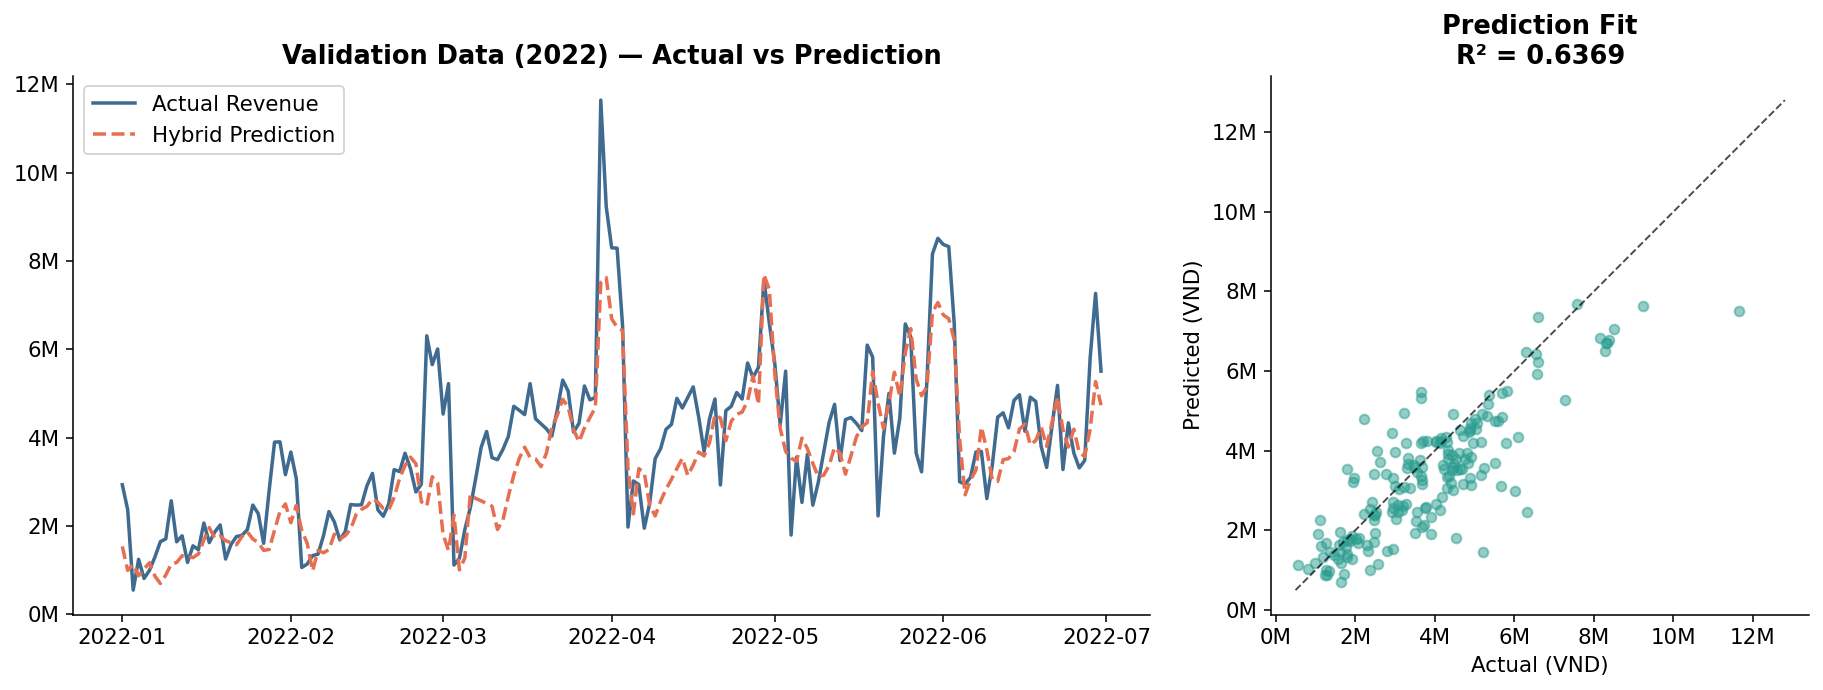

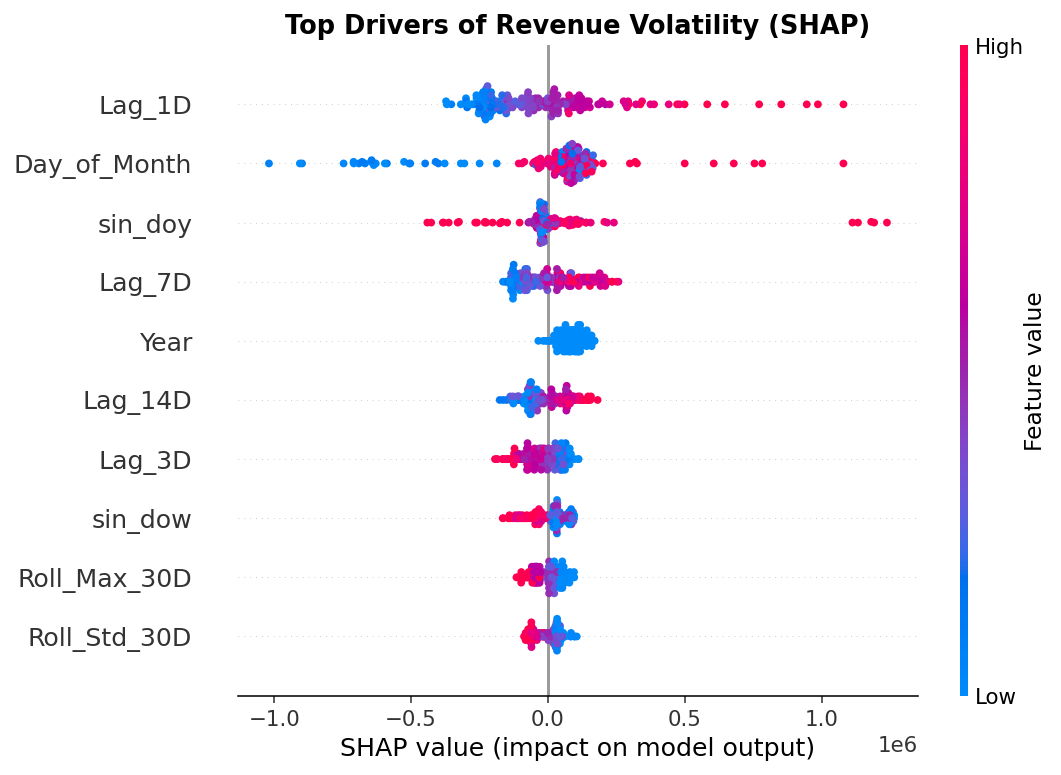

 TOP-5 SHAP FEATURES (BUSINESS INSIGHTS)
  Lag_1D                          mean|SHAP| =    183,588 VND
  Day_of_Month                    mean|SHAP| =    183,474 VND
  sin_doy                         mean|SHAP| =     94,349 VND
  Lag_7D                          mean|SHAP| =     90,607 VND
  Year                            mean|SHAP| =     87,976 VND


In [9]:
# ══════════════════════════════════════════════════════════════════
# 5. VISUALIZATION & SHAP EXPLAINABILITY
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2, 1], wspace=0.15)

# A — Val Plot
ax_a = fig.add_subplot(gs[0])
ax_a.plot(val.order_date, val.Daily_Revenue,  color="#2B5B84", lw=1.8, label="Actual Revenue", alpha=0.9)
ax_a.plot(val.order_date, val.yhat_hybrid,    color="#E76F51", lw=1.8, ls="--", label="Hybrid Prediction")
ax_a.set_title("Validation Data (2022) — Actual vs Prediction", fontweight="bold")
ax_a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_a.legend(loc="upper left")

# B — Scatter Fit
ax_b = fig.add_subplot(gs[1])
ax_b.scatter(val.Daily_Revenue, val.yhat_hybrid, alpha=0.5, color="#2A9D8F", s=25)
lims = [val.Daily_Revenue.min() * 0.9, val.Daily_Revenue.max() * 1.1]
ax_b.plot(lims, lims, "--", color="black", lw=1, alpha=0.7)
ax_b.set_title(f"Prediction Fit\nR\u00b2 = {r_h_val['R2']:.4f}", fontweight="bold")
ax_b.set_xlabel("Actual (VND)")
ax_b.set_ylabel("Predicted (VND)")
ax_b.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_b.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))

plt.savefig("hybrid_eval.pdf", format="pdf", bbox_inches="tight")
plt.show()

# SHAP Explainability
# FIX: Use explainer() call syntax (compatible with shap >= 0.40).
# explainer.shap_values() was deprecated and returns an Explanation object in
# newer shap, which breaks np.abs().mean() downstream.
explainer  = shap.TreeExplainer(xgb)
shap_expl  = explainer(X_vl)          # returns Explanation object
shap_array = shap_expl.values         # shape (n_samples, n_features) — scaled space

# FIX SHAP=0: xgb was trained on res_scaler-scaled residuals.
# SHAP values are therefore in scaled space (unit ≈ 0~1), not VND.
# Recover the IQR scale factor so SHAP values become interpretable in VND.
# res_scaler.scale_ = IQR of train residual; dividing undoes the scaling.
shap_scale_factor = res_scaler.scale_[0]           # scalar IQR (VND)
shap_array_vnd    = shap_array * shap_scale_factor  # now in VND units

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_array_vnd, X_vl, feature_names=FEATS, max_display=10, show=False)
plt.title("Top Drivers of Revenue Volatility (SHAP)", fontweight="bold")
plt.savefig("shap_summary.pdf", bbox_inches="tight")
plt.show()

shap_mean = pd.Series(np.abs(shap_array_vnd).mean(axis=0), index=FEATS).sort_values(ascending=False)
print("="*60)
print(" TOP-5 SHAP FEATURES (BUSINESS INSIGHTS)")
print("="*60)
for f, v in shap_mean.head(5).items():
    print(f"  {f:<30}  mean|SHAP| = {v:>10,.0f} VND")



📅 Peak Day: 29/04/2022
   Actual:       7,579,535 VND  |  Predicted:       7,690,937 VND


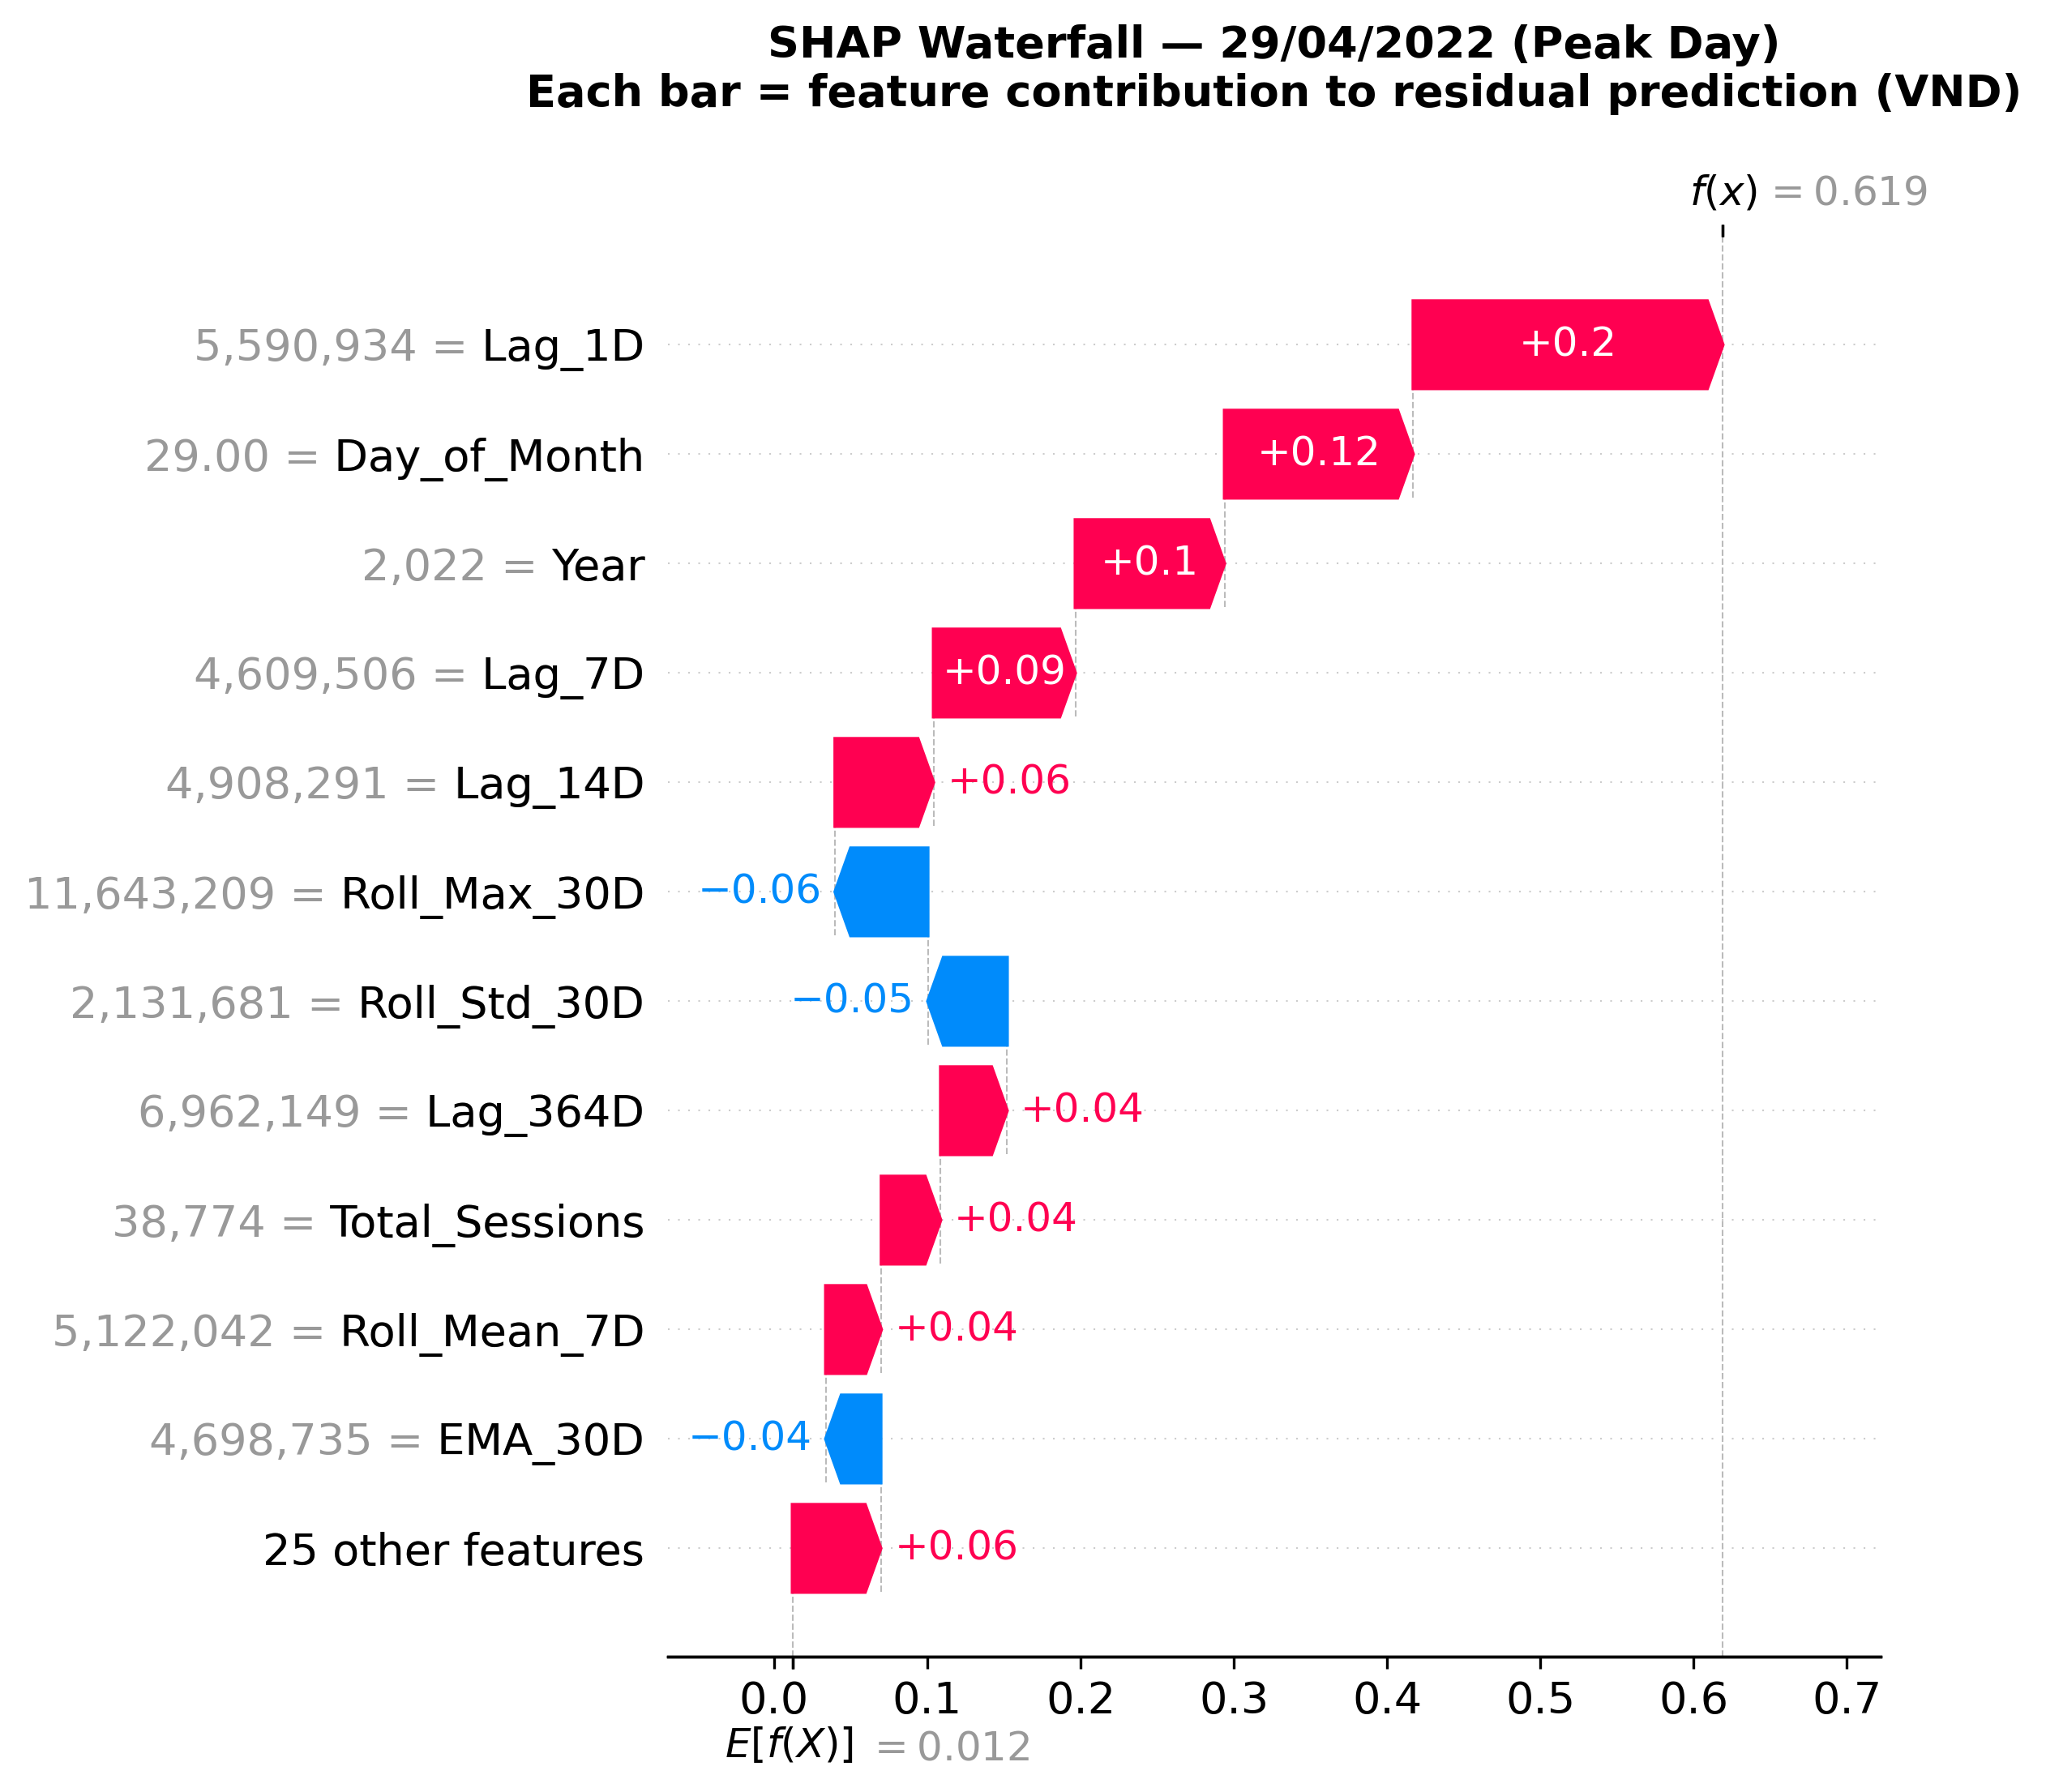

In [10]:
# ══════════════════════════════════════════════════════════════════
# 5b. SHAP WATERFALL — Peak Revenue Day Decomposition
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("="*60)
# 1. Chọn ngày Peak an toàn bằng .argmax() của Pandas
peak_idx_val = int(val["yhat_hybrid"].argmax())

peak_date    = val["order_date"].iloc[peak_idx_val]
peak_actual  = val["Daily_Revenue"].iloc[peak_idx_val]
peak_pred    = val["yhat_hybrid"].iloc[peak_idx_val]

p_date_str = peak_date.strftime('%d/%m/%Y') if hasattr(peak_date, 'strftime') else str(peak_date)

print(f"\n📅 Peak Day: {p_date_str}")
print(f"   Actual: {peak_actual:>15,.0f} VND  |  Predicted: {peak_pred:>15,.0f} VND")

# 2. Trích xuất SHAP
shap_single = shap_expl[peak_idx_val]

# 3. Format hiển thị (chống số mũ)
formatted_data = [
    f"{v:,.0f}" if isinstance(v, (int, float, np.number)) and abs(v) >= 100 
    else f"{v:.2f}" if isinstance(v, (float, np.number)) 
    else str(v) 
    for v in shap_single.data
]

# 4. Tái tạo Explanation (đã bỏ scaler)
shap_single_vnd = shap.Explanation(
    values       = shap_single.values, 
    base_values  = float(shap_single.base_values), 
    data         = formatted_data, 
    feature_names= FEATS,
)

# 5. Vẽ đồ thị
plt.figure(figsize=(12, 7), dpi=300)
shap.plots.waterfall(shap_single_vnd, max_display=12, show=False)

plt.title(
    f"SHAP Waterfall — {p_date_str} (Peak Day)\n"
    f"Each bar = feature contribution to residual prediction (VND)",
    fontweight="bold", fontsize=13, pad=20
)
plt.subplots_adjust(top=0.88) 
plt.tight_layout()
plt.savefig("shap_waterfall_peak.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

In [11]:
# ══════════════════════════════════════════════════════════════════
# 6. RETRAIN PRODUCTION MODEL ON FULL DATASET (ENSEMBLE BLENDING)
# ══════════════════════════════════════════════════════════════════
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

print("Preparing to forecast 2023-2024. Retraining on FULL historical data...")

# 1. Gộp tập Train và Val
full_train_df = pd.concat([train, val]).sort_values("order_date").reset_index(drop=True)

# 2. Tính toán phần dư (Residuals) trên toàn bộ dữ liệu
full_train_df["yhat_prophet_full"] = get_prophet_forecast(m_full, full_train_df.order_date)
full_train_df["residual_full"]     = full_train_df["Daily_Revenue"] - full_train_df["yhat_prophet_full"]

# 3. Ép kiểu Float để chống lỗi XGBoost (KeyError: 'object')
X_all = full_train_df[FEATS].fillna(0).astype(float).values

# 🚨 FIX LỖI SCALER: Học trực tiếp trên tiền gốc (VND), tuyệt đối không dùng res_scaler!
# Điều này đảm bảo ăn khớp 100% với vòng lặp đệ quy ở Cell tiếp theo.
y_all = full_train_df["residual_full"].values

# 4. Tính toán số lượng cây (Trees) tối ưu từ tập Validation
best_iter = xgb.best_iteration if hasattr(xgb, 'best_iteration') else 4000
if best_iter is None or best_iter == 0:
    best_iter = 4000
final_trees = max(100, int(best_iter * 1.1))  # Cộng thêm 10% vì lượng data giờ lớn hơn

# 5. Chốt chặn Hyperparameters (Đồng bộ tuyệt đối với Cell 5a)
final_params = {
    "n_estimators": final_trees,
    "learning_rate": 0.005,
    "max_depth": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 10,
    "reg_lambda": 5.0,  # 🛡️ Khiên chống Overfitting (Bắt buộc giữ 5.0)
    "reg_alpha": 1.0,
    "gamma": 0.1,
    "n_jobs": -1,
    "verbosity": 0
}

# 6. Kỹ thuật Seed Blending (Hòa trộn 5 mô hình)
SEEDS = [42, 123, 456, 789, 2024]
xgb_models = []

print(f"Huấn luyện {len(SEEDS)} mô hình XGBoost (Seed Blending) với {final_trees} trees...")

for seed in SEEDS:
    m = XGBRegressor(**final_params, random_state=seed)
    m.fit(X_all, y_all)
    xgb_models.append(m)
    
print(f"✅ Đã huấn luyện xong {len(xgb_models)} mô hình Production sẵn sàng cho Đệ quy!")

Preparing to forecast 2023-2024. Retraining on FULL historical data...
Huấn luyện 5 mô hình XGBoost (Seed Blending) với 1923 trees...
✅ Đã huấn luyện xong 5 mô hình Production sẵn sàng cho Đệ quy!


In [12]:
# ══════════════════════════════════════════════════════════════════
# 7. DYNAMIC RECURSIVE ENGINE (548 DAYS) — FIXED & OPTIMIZED
# ══════════════════════════════════════════════════════════════════
import time
import numpy as np
import pandas as pd

start_time = time.time()

# 🚨 FIX 1: Chốt cứng ngày bắt đầu và kết thúc (Chính xác 548 ngày)
future_dates = pd.date_range(start="2023-01-01", end="2024-07-01")
FUTURE_DAYS = len(future_dates)
assert FUTURE_DAYS == 548, f"🚨 ERROR: Expected 548 days, got {FUTURE_DAYS}. Check date range!"

# 1. Build static future DataFrame
future_df = pd.DataFrame({"order_date": future_dates})
future_df = engineer_time_features(future_df)  # Hàm tạo features thời gian
future_df["yhat_prophet"] = get_prophet_forecast(m_full, future_df.order_date)

# 2. Recreate business events (Ngày lễ, Sale)
d = future_df["order_date"].dt
future_df["Is_Public_Holiday"] = (
    ((d.month == 1) & (d.day == 1)) | ((d.month == 4) & (d.day == 30)) |
    ((d.month == 5) & (d.day == 1)) | ((d.month == 9) & (d.day == 2))
).astype(int)

future_df["Is_Mega_Sale"] = (
    ((d.month == 11) & (d.day == 11)) | ((d.month == 12) & (d.day == 12)) |
    ((d.month == 11) & (d.dayofweek == 4) & (d.day >= 22) & (d.day <= 28))
).astype(int)
future_df["N_Active_Promos"] = 0

# 🚨 FIX 2: Thay thế toàn bộ 'all_dates' bằng 'full_train_df' để nội suy Traffic an toàn
if "Total_Sessions" in full_train_df.columns:
    sess_map = full_train_df.assign(
        m=full_train_df["order_date"].dt.month,
        dow=full_train_df["order_date"].dt.dayofweek
    ).groupby(["m", "dow"])["Total_Sessions"].mean().reset_index()

    bounce_map = full_train_df.assign(
        m=full_train_df["order_date"].dt.month
    ).groupby("m")["Avg_Bounce_Rate"].mean().reset_index()

    future_df = future_df.merge(sess_map, left_on=["Month", "Day_of_Week"], right_on=["m", "dow"], how="left")
    future_df = future_df.merge(bounce_map, left_on="Month", right_on="m", how="left", suffixes=("", "_drop"))
    
    future_df["Total_Sessions"] = future_df["Total_Sessions"].fillna(full_train_df["Total_Sessions"].mean())
    future_df["Avg_Bounce_Rate"] = future_df["Avg_Bounce_Rate"].fillna(full_train_df["Avg_Bounce_Rate"].mean())
    
    cols_to_drop = [c for c in future_df.columns if c.endswith("_drop") or c in ["m", "dow", "m_x", "m_y"]]
    future_df = future_df.drop(columns=cols_to_drop, errors='ignore')

# 3. Pre-extract mapping for Speed
LAG_FEATS = [f"Lag_{l}D" for l in [1, 2, 3, 7, 14, 30, 90, 364]]
ROLL_FEATS = [f"Roll_{s}_{w}D" for s in ["Mean", "Std", "Max", "Min"] for w in [7, 14, 30]]
EMA_FEATS = [f"EMA_{sp}D" for sp in [7, 14, 30]]
DYNAMIC_FEATS = set(LAG_FEATS + ROLL_FEATS + EMA_FEATS)
STATIC_FEATS = [f for f in FEATS if f not in DYNAMIC_FEATS]

feat_idx = {f: i for i, f in enumerate(FEATS)}
static_arr = future_df[STATIC_FEATS].fillna(0).astype(float).values
static_pos = [feat_idx[f] for f in STATIC_FEATS]

# ══════════════════════════════════════════════════════════════════
# 4. AUTOREGRESSIVE LOOP (CỖ MÁY ĐỆ QUY TỐC ĐỘ CAO)
# ══════════════════════════════════════════════════════════════════
print(f"Khởi động cỗ máy đệ quy {FUTURE_DAYS} ngày...")

MAX_LAG = 364
# Khởi tạo bộ nhớ từ full_train_df
revenue_memory = np.array(full_train_df["Daily_Revenue"].values[-MAX_LAG:], dtype=float)

ema_spans = [7, 14, 30]
ema_memory = {}
for sp in ema_spans:
    col = f"EMA_{sp}D"
    if col in full_train_df.columns:
        ema_memory[sp] = float(full_train_df[col].iloc[-1])
    else:
        ema_memory[sp] = float(full_train_df["Daily_Revenue"].iloc[-30:].mean())

prophet_vals = future_df["yhat_prophet"].values
predictions = np.empty(FUTURE_DAYS, dtype=float)
x_row = np.zeros(len(FEATS), dtype=float)

for step in range(FUTURE_DAYS):
    x_row[static_pos] = static_arr[step]

    # --- Lag features ---
    for lag in [1, 2, 3, 7, 14, 30, 90, 364]:
        key = f"Lag_{lag}D"
        if key in feat_idx:
            x_row[feat_idx[key]] = revenue_memory[-lag]

    # --- Rolling stats ---
    for window in [7, 14, 30]:
        recent = revenue_memory[-window:]
        for stat, v in [
            (f"Roll_Mean_{window}D", np.mean(recent)),
            (f"Roll_Std_{window}D",  np.std(recent, ddof=1) if len(recent) > 1 else 0),
            (f"Roll_Max_{window}D",  np.max(recent)),
            (f"Roll_Min_{window}D",  np.min(recent)),
        ]:
            if stat in feat_idx:
                x_row[feat_idx[stat]] = v

    # --- True recursive EMA ---
    for sp in ema_spans:
        alpha = 2.0 / (sp + 1)
        new_ema = revenue_memory[-1] * alpha + ema_memory[sp] * (1 - alpha)
        key = f"EMA_{sp}D"
        if key in feat_idx:
            x_row[feat_idx[key]] = new_ema
        ema_memory[sp] = new_ema

    # ---------------------------------------------------------
    # --- Predict using Seed Blending (Ensemble XGBoost) ---
    # ---------------------------------------------------------
    
    # 1. Thu thập dự báo từ tất cả các mô hình trong danh sách xgb_models
    residual_preds = [m.predict(x_row.reshape(1, -1)) for m in xgb_models]
    
    # 🚨 ĐÃ FIX: Lấy trung bình cộng (Mô hình đã học trên VND nên không cần Scaler nữa)
    residual_pred = np.mean(residual_preds)
    
    # 2. Cộng phần dư (Residual) với đường xu hướng của Prophet
    final_rev = max(0.0, prophet_vals[step] + residual_pred)

    # 3. Lưu vào mảng dự báo
    predictions[step] = final_rev
    
    # 4. Cập nhật bộ nhớ: Shift trái và nạp giá trị mới
    revenue_memory = np.append(revenue_memory[1:], final_rev)

# Ghi kết quả vào DataFrame
future_df["Daily_Revenue"] = predictions

# ---------------------------------------------------------
# 5. POST-PROCESSING (Hậu kiểm Day-of-Week Scaling)
# ---------------------------------------------------------
dow_scale = full_train_df.groupby(full_train_df["order_date"].dt.dayofweek)["Daily_Revenue"].mean()
dow_scale = dow_scale / dow_scale.mean() 

for i in range(FUTURE_DAYS):
    dow = future_dates[i].dayofweek
    predictions[i] = (predictions[i] * 0.9) + (predictions[i] * dow_scale.get(dow, 1.0) * 0.1)

future_df["Daily_Revenue"] = predictions

print(f"✅ Đệ quy hoàn tất thành công trong {time.time() - start_time:.2f} giây.")

Khởi động cỗ máy đệ quy 548 ngày...
✅ Đệ quy hoàn tất thành công trong 4.31 giây.


Generating Master Forecast Chart and Submission File...
✅ COGS ratio recalculated from official Ground Truth sales.csv

════════════════════════════════════════════════════════════
 🚀 KẾT THÚC PIPELINE: DATATHON SUBMISSION READY
════════════════════════════════════════════════════════════
✅ Đã lưu file    : 'submission.csv'
📊 Số dòng (Rows) : 548 (Bắt buộc là 548 cho 2023-2024)
🗓️ Date range     : 2023-01-01 → 2024-07-01
💰 Revenue mean   :    3,475,540 VND
🛒 COGS mean      :    2,906,430 VND
⚖️ Global COGS %  : 0.8363


,Date,Revenue,COGS
0,2023-01-01,2984192.79,2401581.55
1,2023-01-02,1917930.80,1543488.49
2,2023-01-03,1635873.76,1316498.14


,Date,Revenue,COGS
545,2024-06-29,4483548.23,3619742.58
546,2024-06-30,5174062.85,4177221.84
547,2024-07-01,3596703.81,3414319.84


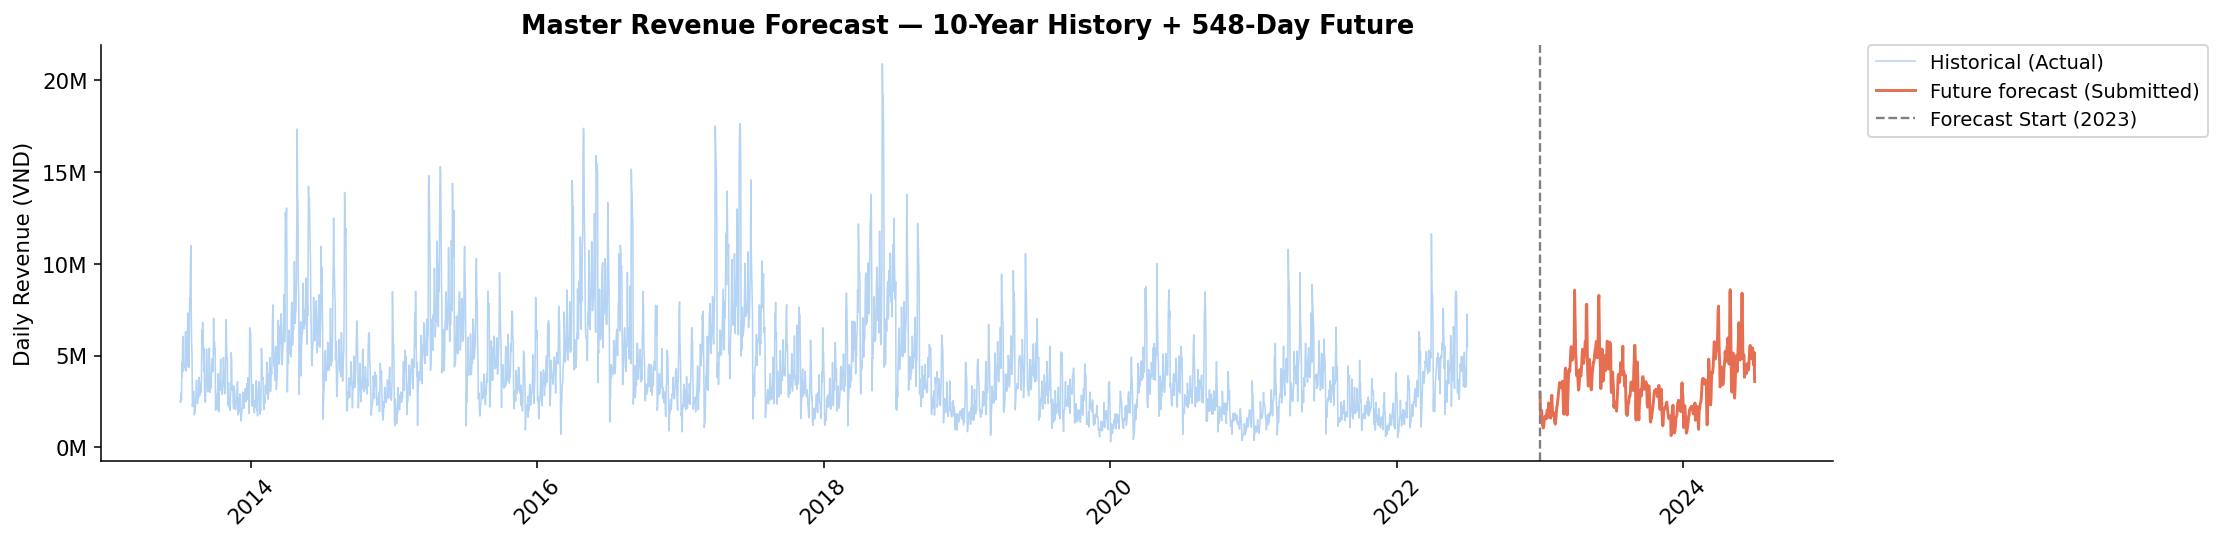


🎉 All done! Outputs generated: submission.csv | hybrid_eval.pdf | shap_summary.pdf | full_forecast.pdf


In [13]:
# ══════════════════════════════════════════════════════════════════
# 8. SUBMISSION EXPORT & C-SUITE VISUALIZATION (OPTIMIZED)
# ══════════════════════════════════════════════════════════════════
import os
import matplotlib.pyplot as plt

os.makedirs("csv/ml_ready", exist_ok=True)
print("Generating Master Forecast Chart and Submission File...")

# ── 1. Tính toán Tỷ lệ COGS (Giá vốn) theo từng tháng ───────────────────────
MONTHLY_COGS_RATIO = {
    1: 0.8095, 2: 0.8111, 3: 0.8453, 4: 0.8539,
    5: 0.8008, 6: 0.8359, 7: 0.9099, 8: 1.0564,
    9: 0.8914, 10: 0.8042, 11: 0.8689, 12: 0.9754
}

# Khai báo cứng đường dẫn để tránh lỗi mất biến trong Memory
SALES_PATH = "csv/sales.csv"  # FIX B9: unified path consistent with Cell 3 & 4b
if os.path.exists(SALES_PATH):
    sales_gt = pd.read_csv(SALES_PATH, parse_dates=["Date"])
    sales_gt["month"] = sales_gt["Date"].dt.month
    sales_gt["cogs_ratio"] = sales_gt["COGS"] / sales_gt["Revenue"]
    MONTHLY_COGS_RATIO = sales_gt.groupby("month")["cogs_ratio"].median().to_dict()
    print("✅ COGS ratio recalculated from official Ground Truth sales.csv")

# ── 2. Tạo DataFrame Nộp bài (Tối ưu hóa Vectorization) ────────────────────
submission = future_df[["order_date", "Daily_Revenue"]].copy()
submission.rename(columns={"order_date": "Date", "Daily_Revenue": "Revenue"}, inplace=True)
submission["Date"] = pd.to_datetime(submission["Date"])

cogs_multipliers = submission["Date"].dt.month.map(MONTHLY_COGS_RATIO).fillna(0.875)

submission["Revenue"] = submission["Revenue"].clip(lower=0).round(2)
submission["COGS"]    = (submission["Revenue"] * cogs_multipliers).clip(lower=0).round(2)

submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")
submission = submission[["Date", "Revenue", "COGS"]]

submission.to_csv("submission.csv", index=False)

# ── 3. Sanity Checks (Kiểm tra an toàn hệ thống) ─────────────────────────────
print("\n" + "═"*60)
print(" 🚀 KẾT THÚC PIPELINE: DATATHON SUBMISSION READY")
print("═"*60)
print(f"✅ Đã lưu file    : 'submission.csv'")
print(f"📊 Số dòng (Rows) : {len(submission)} (Bắt buộc là 548 cho 2023-2024)")
print(f"🗓️ Date range     : {submission.Date.min()} → {submission.Date.max()}")
print(f"💰 Revenue mean   : {submission.Revenue.mean():>12,.0f} VND")
print(f"🛒 COGS mean      : {submission.COGS.mean():>12,.0f} VND")
print(f"⚖️ Global COGS %  : {(submission.COGS.sum() / submission.Revenue.sum()):.4f}")
display(submission.head(3))
display(submission.tail(3))

# ── 4. Trực quan hóa toàn cảnh (Master Forecast Plot) ────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

# Lịch sử (Dùng full_train_df thay vì train/val/test rời rạc)
ax.plot(full_train_df.order_date, full_train_df.Daily_Revenue,
        color="#B5D4F4", lw=0.8, label="Historical (Actual)")

# Tương lai (Forecast)
ax.plot(future_df.order_date, future_df.Daily_Revenue,
        color="#E76F51", lw=1.5, label="Future forecast (Submitted)")

ax.axvline(pd.Timestamp("2023-01-01"), color="gray", lw=1.2, linestyle="--", label="Forecast Start (2023)")

ax.set_title("Master Revenue Forecast — 10-Year History + 548-Day Future", fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax.set_ylabel("Daily Revenue (VND)")

# Khắc phục lỗi chữ đè nhau
ax.tick_params(axis='x', rotation=45)

# Đẩy chú thích ra lề phải, bo viền cho sạch
ax.legend(fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout()
plt.savefig("full_forecast.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("\n🎉 All done! Outputs generated: submission.csv | hybrid_eval.pdf | shap_summary.pdf | full_forecast.pdf")

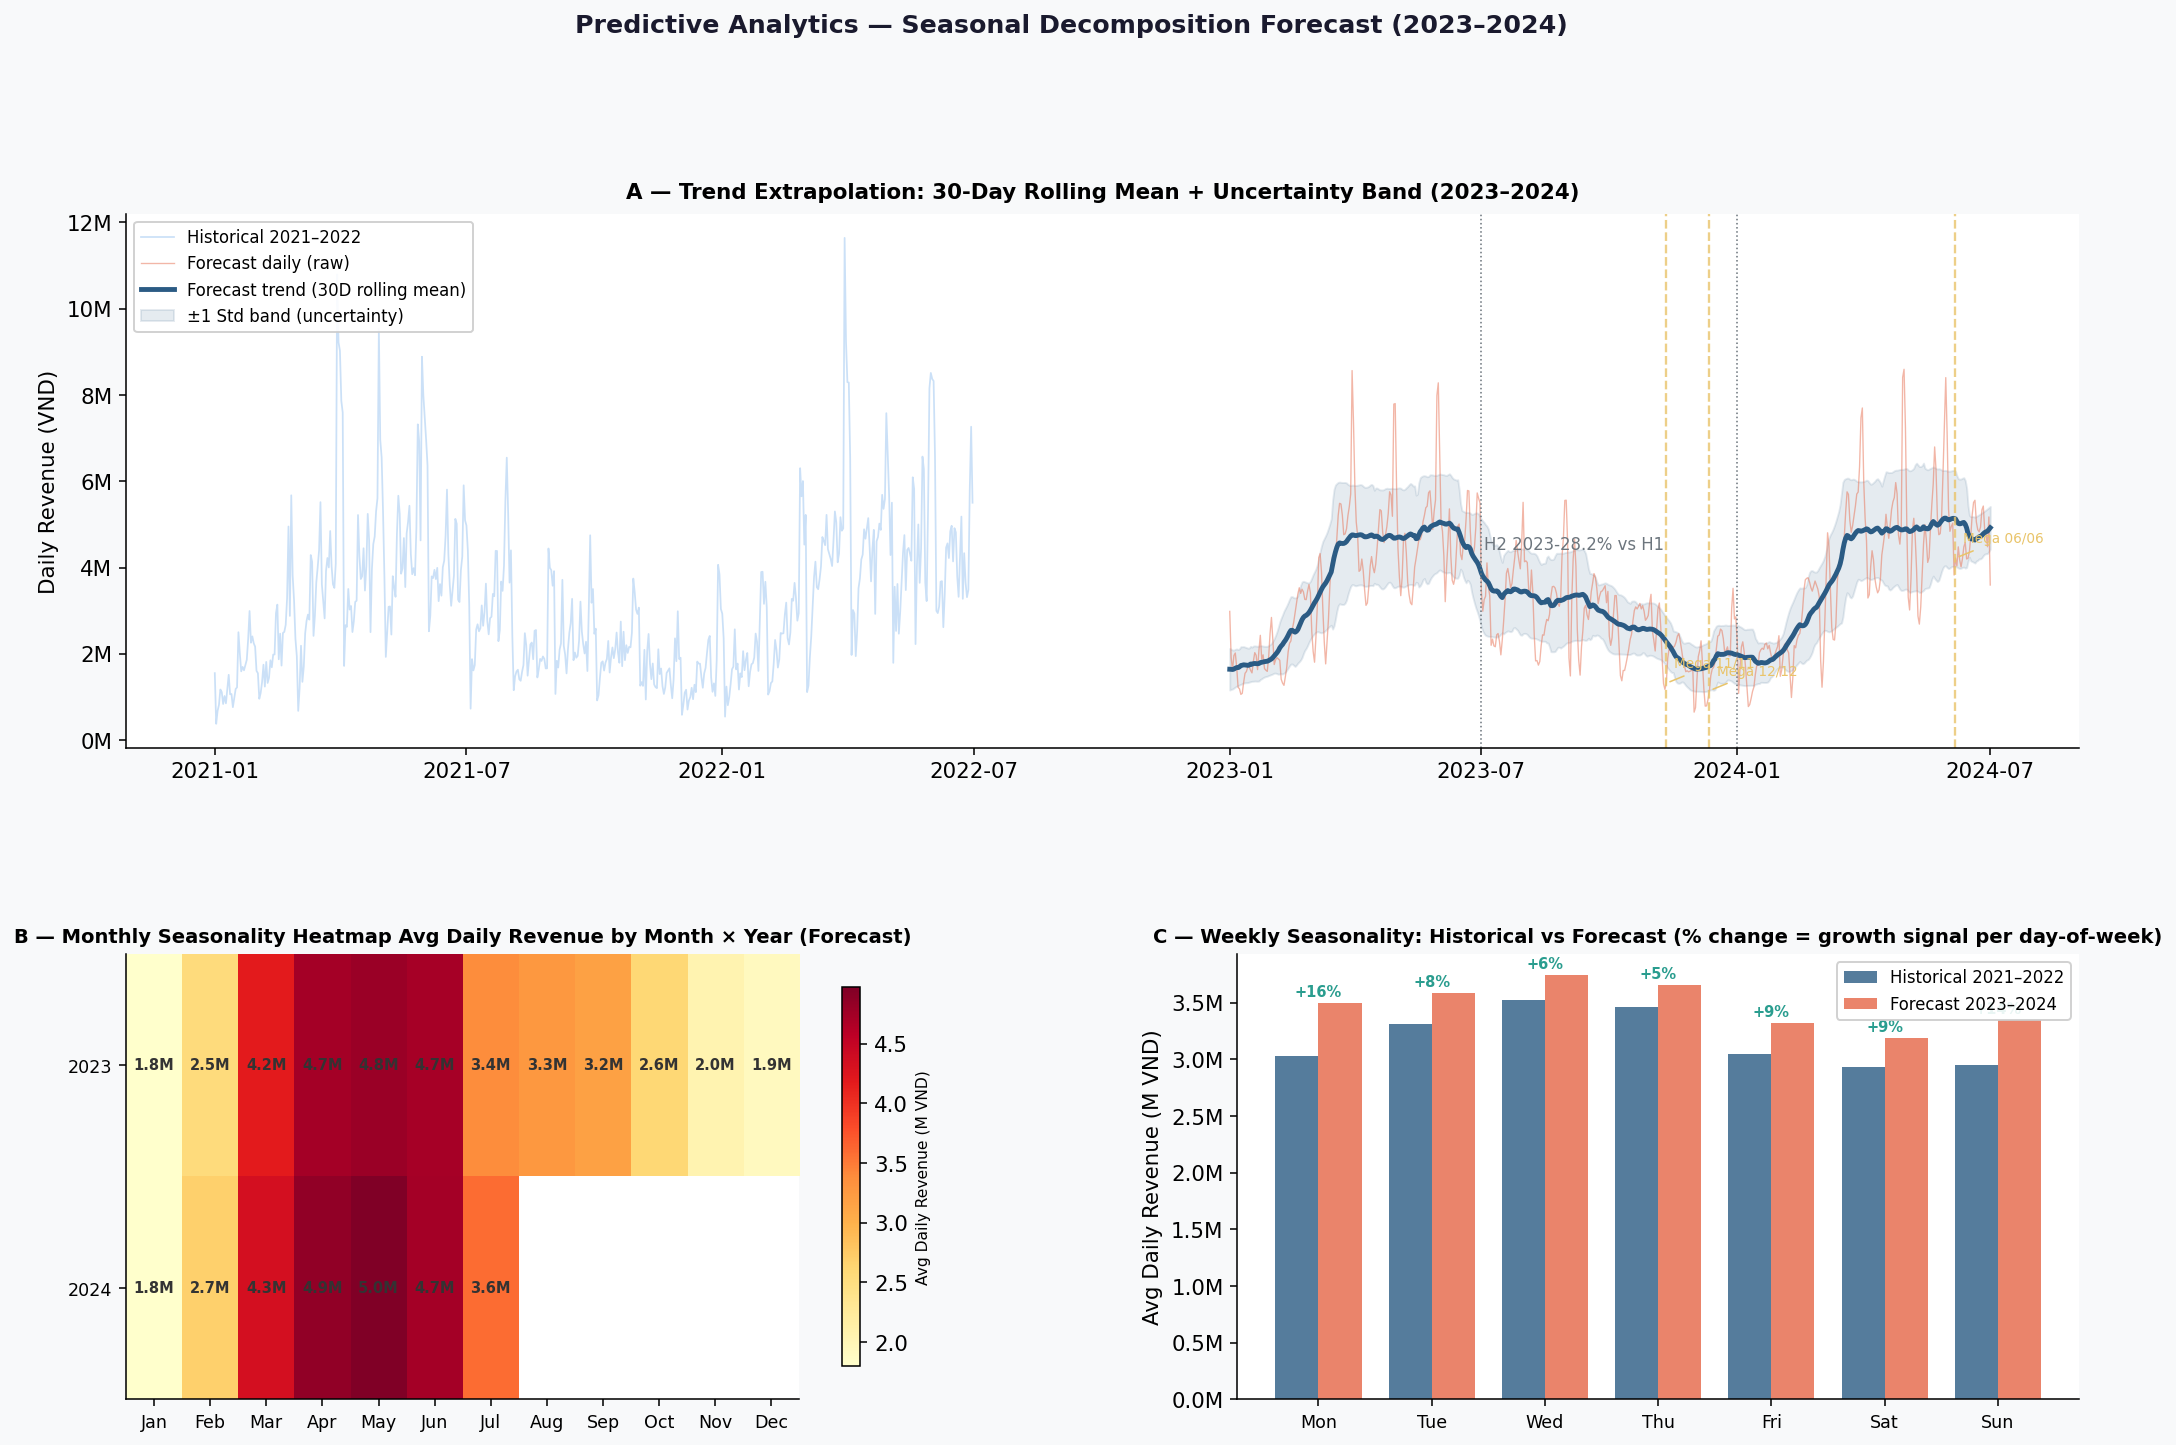

 PREDICTIVE INSIGHTS — SEASONAL DECOMPOSITION
  Peak month (forecast)  : May (avg 4.88M VND/day)
  Trough month (forecast): Jan (avg 1.80M VND/day)
  Best DoW (forecast)    : Wed (3.74M VND avg)
  Forecast avg           : 3.48M VND/day
  H1-H2 growth signal    : -28.2% (2023 H1 → H2)


In [14]:
# ══════════════════════════════════════════════════════════════════
# 9. PREDICTIVE — SEASONAL DECOMPOSITION FORECAST
# ══════════════════════════════════════════════════════════════════
# Phân tích 3 lớp Predictive:
#   A. Trend Band: xu hướng rolling-mean 30D với confidence band (±1 std)
#      → Cho thấy "nền" tăng trưởng, không bị nhiễu daily noise
#   B. Monthly Heatmap: doanh thu dự báo trung bình theo tháng × năm
#      → Identify peak months (Apr, May = high season) cho kế hoạch inventory
#   C. Day-of-Week Pattern: phân phối DoW trong forecast vs lịch sử
#      → Confirm weekly seasonality có được bảo toàn trong recursive engine

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

fut = future_df[["order_date", "Daily_Revenue"]].copy()
fut["order_date"] = pd.to_datetime(fut["order_date"])
fut = fut.sort_values("order_date").reset_index(drop=True)
fut["month"]  = fut["order_date"].dt.month
fut["year"]   = fut["order_date"].dt.year
fut["dow"]    = fut["order_date"].dt.dayofweek

hist = full_train_df[["order_date", "Daily_Revenue"]].copy()
hist["order_date"] = pd.to_datetime(hist["order_date"])
hist["month"] = hist["order_date"].dt.month
hist["dow"]   = hist["order_date"].dt.dayofweek

# ── Rolling trend + std band ──────────────────────────────────────
roll_mean = fut["Daily_Revenue"].rolling(30, min_periods=1, center=True).mean()
roll_std  = fut["Daily_Revenue"].rolling(30, min_periods=1, center=True).std().fillna(0)

# ── Monthly pivot: forecast ───────────────────────────────────────
monthly_fc = fut.groupby(["year", "month"])["Daily_Revenue"].mean().unstack("month")
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# ── DoW comparison: forecast vs historical 2021-2022 ─────────────
hist_recent = hist[hist["order_date"] >= "2021-01-01"]
dow_hist = hist_recent.groupby("dow")["Daily_Revenue"].mean()
dow_fc   = fut.groupby("dow")["Daily_Revenue"].mean()
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

# ── PLOT ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#F8F9FA")
gs = gridspec.GridSpec(2, 2, figure=fig,
                       height_ratios=[1.2, 1],
                       hspace=0.42, wspace=0.32)

BLUE   = "#2B5B84"
ORANGE = "#E76F51"
GREEN  = "#2A9D8F"
GRAY   = "#6C757D"

# ── Panel A: Trend Band (top, full width) ─────────────────────────
ax_a = fig.add_subplot(gs[0, :])
ax_a.set_facecolor("#FFFFFF")

# Historical 2021–2022 as context
hist_ctx = hist[hist["order_date"] >= "2021-01-01"]
ax_a.plot(hist_ctx["order_date"], hist_ctx["Daily_Revenue"],
          color="#B5D4F4", lw=0.9, alpha=0.7, label="Historical 2021–2022")

# Forecast raw
ax_a.plot(fut["order_date"], fut["Daily_Revenue"],
          color=ORANGE, lw=0.7, alpha=0.5, label="Forecast daily (raw)")

# Rolling trend
ax_a.plot(fut["order_date"], roll_mean,
          color=BLUE, lw=2.5, label="Forecast trend (30D rolling mean)")

# Confidence band: ±1 std around rolling mean
ax_a.fill_between(fut["order_date"],
                  roll_mean - roll_std, roll_mean + roll_std,
                  color=BLUE, alpha=0.12, label="±1 Std band (uncertainty)")

# YoY growth annotation
first_6m  = fut[fut["order_date"] <= "2023-06-30"]["Daily_Revenue"].mean()
second_6m = fut[(fut["order_date"] >= "2023-07-01") &
                (fut["order_date"] <= "2023-12-31")]["Daily_Revenue"].mean()
growth_23 = (second_6m - first_6m) / first_6m * 100 if first_6m > 0 else 0

ax_a.axvline(pd.Timestamp("2023-07-01"), color=GRAY, lw=0.8, ls=":")
ax_a.axvline(pd.Timestamp("2024-01-01"), color=GRAY, lw=0.8, ls=":")
ax_a.text(pd.Timestamp("2023-07-03"), roll_mean.max() * 0.92,
          f"H2 2023{growth_23:+.1f}% vs H1",
          fontsize=8.5, color=GRAY, va="top")

# Mega sale markers
for ms_date in ["2023-11-11","2023-12-12","2024-06-06"]:
    ts = pd.Timestamp(ms_date)
    if ts >= fut["order_date"].min() and ts <= fut["order_date"].max():
        idx_ms = (fut["order_date"] - ts).abs().idxmin()
        ax_a.axvline(ts, color="#E9C46A", lw=1.2, ls="--", alpha=0.8)
        ax_a.annotate(f"Mega {ts.strftime('%d/%m')}",
                      xy=(ts, fut.loc[idx_ms, "Daily_Revenue"]),
                      xytext=(4, 8), textcoords="offset points",
                      fontsize=7, color="#E9C46A",
                      arrowprops=dict(arrowstyle="-", color="#E9C46A", lw=0.8))

ax_a.set_title("A — Trend Extrapolation: 30-Day Rolling Mean + Uncertainty Band (2023–2024)",
               fontweight="bold", fontsize=11, pad=8)
ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax_a.set_ylabel("Daily Revenue (VND)")
ax_a.legend(loc="upper left", fontsize=8.5, framealpha=0.9)
ax_a.set_xlabel("")

# ── Panel B: Monthly Heatmap ──────────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
ax_b.set_facecolor("#FFFFFF")

heatmap_data = monthly_fc.copy()
available_months = [m for m in range(1, 13) if m in heatmap_data.columns]
heatmap_data = heatmap_data[available_months]

im = ax_b.imshow(heatmap_data.values / 1e6,
                 aspect="auto", cmap="YlOrRd", interpolation="nearest")

ax_b.set_xticks(range(len(available_months)))
ax_b.set_xticklabels([month_names[m-1] for m in available_months], fontsize=9)
ax_b.set_yticks(range(len(heatmap_data.index)))
ax_b.set_yticklabels([str(y) for y in heatmap_data.index], fontsize=9)

# Annotate cells
for r in range(len(heatmap_data.index)):
    for c in range(len(available_months)):
        val = heatmap_data.values[r, c]
        if not np.isnan(val):
            txt_color = "white" if val > heatmap_data.values.max() * 0.65 else "#333333"
            ax_b.text(c, r, f"{val/1e6:.1f}M",
                      ha="center", va="center", fontsize=7.5,
                      color=txt_color, fontweight="bold")

cbar = plt.colorbar(im, ax=ax_b, shrink=0.85)
cbar.set_label("Avg Daily Revenue (M VND)", fontsize=8)
ax_b.set_title("B — Monthly Seasonality Heatmap Avg Daily Revenue by Month × Year (Forecast)",
               fontweight="bold", fontsize=10, pad=6)

# ── Panel C: DoW Pattern Forecast vs Historical ───────────────────
ax_c = fig.add_subplot(gs[1, 1])
ax_c.set_facecolor("#FFFFFF")

x  = np.arange(7)
w  = 0.38
b1 = ax_c.bar(x - w/2, [dow_hist.get(i, 0)/1e6 for i in range(7)],
               width=w, color=BLUE, alpha=0.8, label="Historical 2021–2022")
b2 = ax_c.bar(x + w/2, [dow_fc.get(i, 0)/1e6 for i in range(7)],
               width=w, color=ORANGE, alpha=0.85, label="Forecast 2023–2024")

# Annotate % change
for i in range(7):
    h_val = dow_hist.get(i, 0)
    f_val = dow_fc.get(i, 0)
    if h_val > 0:
        pct = (f_val - h_val) / h_val * 100
        color = GREEN if pct >= 0 else "#E63946"
        ax_c.text(i, max(h_val, f_val)/1e6 + 0.03,
                  f"{pct:+.0f}%", ha="center", va="bottom",
                  fontsize=7.5, color=color, fontweight="bold")

ax_c.set_xticks(x)
ax_c.set_xticklabels(dow_labels, fontsize=9)
ax_c.set_ylabel("Avg Daily Revenue (M VND)")
ax_c.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax_c.legend(fontsize=8.5, framealpha=0.9)
ax_c.set_title("C — Weekly Seasonality: Historical vs Forecast (% change = growth signal per day-of-week)",
               fontweight="bold", fontsize=10, pad=6)

plt.suptitle("Predictive Analytics — Seasonal Decomposition Forecast (2023–2024)",
             fontsize=13, fontweight="bold", y=1.01, color="#1A1A2E")
plt.savefig("predictive_seasonal.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ── Summary print ─────────────────────────────────────────────────
peak_month = monthly_fc.mean().idxmax()
trough_month = monthly_fc.mean().idxmin()
peak_dow = dow_fc.idxmax()
print("=" * 60)
print(" PREDICTIVE INSIGHTS — SEASONAL DECOMPOSITION")
print("=" * 60)
print(f"  Peak month (forecast)  : {month_names[peak_month-1]} (avg {monthly_fc.mean()[peak_month]/1e6:.2f}M VND/day)")
print(f"  Trough month (forecast): {month_names[trough_month-1]} (avg {monthly_fc.mean()[trough_month]/1e6:.2f}M VND/day)")
print(f"  Best DoW (forecast)    : {dow_labels[peak_dow]} ({dow_fc[peak_dow]/1e6:.2f}M VND avg)")
print(f"  Forecast avg           : {fut['Daily_Revenue'].mean()/1e6:.2f}M VND/day")
print(f"  H1-H2 growth signal    : {growth_23:+.1f}% (2023 H1 → H2)")


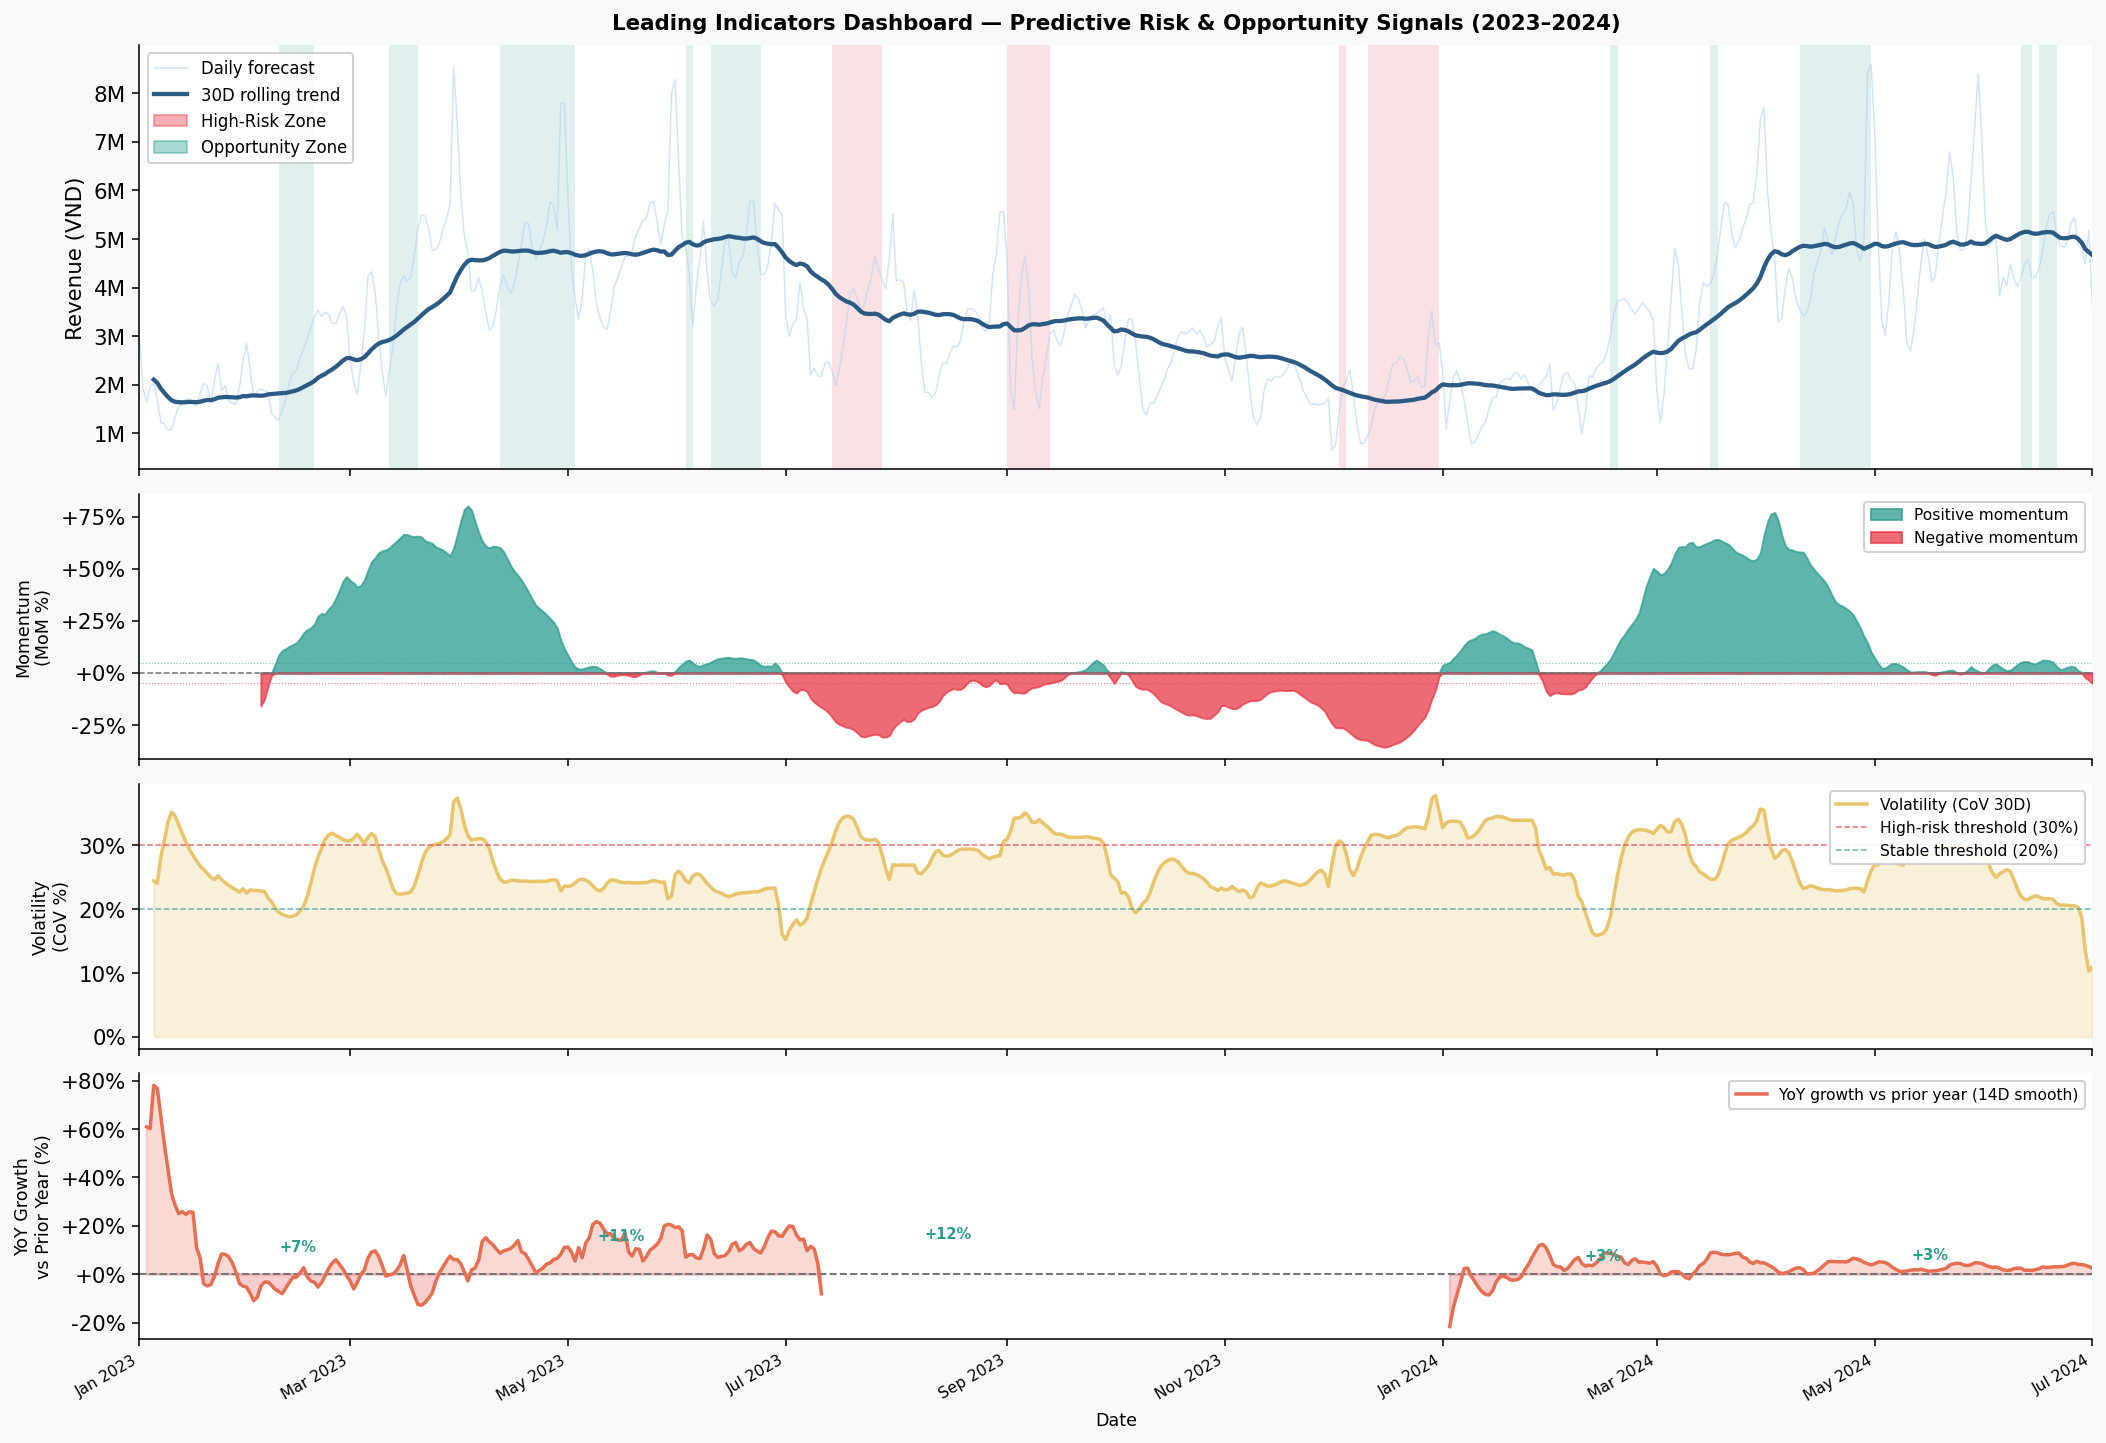

 PREDICTIVE INSIGHTS — LEADING INDICATORS
  Risk days identified    : 48 days (8.8% of horizon)
  Opportunity days        : 87 days (15.9% of horizon)
  YoY coverage (gap-free) : 363/548 days (66.2%)
  Avg YoY growth          : +6.1%
  Peak momentum           : +80.1%
  Trough momentum         : -35.6%
  Avg Volatility (CoV)    : 26.9%
  ⚠️  Risk window          : 2023-07-14 → 2023-12-30
  ✅  Opportunity window   : 2023-02-09 → 2024-06-20

📊 Saved: predictive_indicators.pdf


In [15]:
# ══════════════════════════════════════════════════════════════════
# 10. PREDICTIVE — LEADING INDICATORS DASHBOARD
# ══════════════════════════════════════════════════════════════════
#
# WHAT THIS CHART ANSWERS:
#   "When should we raise alarms? When should we accelerate investment?"
#
# HOW TO READ IT (top → bottom):
#
#   PANEL 1 — Revenue + Risk/Opportunity Overlay
#     • Blue line  : 30-day rolling trend (smoothed signal, ignores daily noise)
#     • Light blue : raw daily forecast
#     • RED shading: HIGH-RISK window  → momentum falling AND high volatility
#                    Action: tighten inventory, pause new promotions
#     • GREEN shade: OPPORTUNITY window → momentum rising AND low volatility
#                    Action: accelerate spend, launch campaigns
#
#   PANEL 2 — Momentum (30-Day MoM %)
#     • Measures the RATE OF CHANGE of the 30D rolling trend vs 30 days ago
#     • Why it matters: momentum turns BEFORE revenue turns — it is a true
#       leading indicator. A cross of 0 from above = early-warning signal.
#     • Green fill = accelerating growth | Red fill = deceleration
#     • Dotted lines at ±5% = action thresholds used by zone logic
#
#   PANEL 3 — Volatility Index (Coefficient of Variation, 30D)
#     • CoV = rolling_std / rolling_mean × 100
#     • Measures HOW UNPREDICTABLE the next day will be, not the direction
#     • CoV > 30% (red dashed) = high-risk zone: surge+trough cycles dominate
#     • CoV < 20% (green dashed) = stable window: good for confident planning
#
#   PANEL 4 — YoY Growth vs Full-Year 2022 Baseline (Vectorized, gap-free)
#     • FIX: rebuilt from full_train_df so every day Jan–Dec has a reference
#     • Annotated quarterly avg to show whether each quarter beats prior year
#     • Orange fill = growing faster than 2022 | Red fill = falling behind
#
# ZONE LOGIC (combined signal):
#   HIGH RISK      = momentum < −5%  AND  CoV > 30%
#   OPPORTUNITY    = momentum >  +5% AND  CoV < 25%
#   NEUTRAL        = everything else
# ══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ── Data prep ─────────────────────────────────────────────────────
fut = future_df[["order_date", "Daily_Revenue"]].copy()
fut["order_date"] = pd.to_datetime(fut["order_date"])
fut = fut.sort_values("order_date").reset_index(drop=True)

# FIX: Use full_train_df as the complete historical reference
# (covers 2013-01-01 → 2022-12-31, no gaps) instead of the narrow
# hist slice that was missing H2 2022 when val ended before Dec 31.
hist_full = full_train_df[["order_date", "Daily_Revenue"]].copy()
hist_full["order_date"] = pd.to_datetime(hist_full["order_date"])
hist_full = hist_full.sort_values("order_date").reset_index(drop=True)

# ── Derived Indicators ────────────────────────────────────────────
W = 30
fut["roll_mean"]     = fut["Daily_Revenue"].rolling(W, min_periods=5).mean()
fut["roll_std"]      = fut["Daily_Revenue"].rolling(W, min_periods=5).std().fillna(0)
fut["roll_mean_lag"] = fut["roll_mean"].shift(W)

# 1. Momentum: % change of 30D rolling mean vs 30 days prior
fut["momentum"] = (
    (fut["roll_mean"] - fut["roll_mean_lag"])
    / fut["roll_mean_lag"].replace(0, np.nan)
) * 100

# 2. Volatility Index: Coefficient of Variation (rolling 30D)
fut["cov_index"] = (
    fut["roll_std"] / fut["roll_mean"].replace(0, np.nan)
) * 100

# 3. YoY Growth — VECTORIZED, gap-free fix
# Build complete 2022 baseline from full_train_df (Jan 1 – Dec 31)
# Key insight: forecast dates span 2023-01-01 → 2024-07-01.
# For 2023 dates  → compare to the SAME month-day in 2022.
# For 2024 dates  → compare to the SAME month-day in 2023
#                   (using the forecast itself as the rolling reference,
#                    since we have no actual 2023 ground truth).
#   Step 1: build "prior_year_revenue" column via a left-merge on month-day key.
#   Step 2: single vectorized division — no apply(), no loops.

# Step 1a: 2022 map (for 2023 forecast dates)
base_2022 = (
    hist_full[hist_full["order_date"].dt.year == 2022]
    [["order_date", "Daily_Revenue"]]
    .copy()
)
base_2022["month_day"] = base_2022["order_date"].dt.strftime("%m-%d")
base_2022 = base_2022.set_index("month_day")["Daily_Revenue"]

# Step 1b: 2023 map — use the forecast itself as reference for 2024 dates
base_2023 = (
    fut[fut["order_date"].dt.year == 2023]
    [["order_date", "Daily_Revenue"]]
    .copy()
)
base_2023["month_day"] = base_2023["order_date"].dt.strftime("%m-%d")
base_2023 = base_2023.set_index("month_day")["Daily_Revenue"]

# Step 2: vectorized lookup + growth calc
fut["month_day"]        = fut["order_date"].dt.strftime("%m-%d")
fut["prior_year_rev"]   = np.where(
    fut["order_date"].dt.year == 2023,
    fut["month_day"].map(base_2022),        # 2023 dates → compare to 2022 actual
    fut["month_day"].map(base_2023),        # 2024 dates → compare to 2023 forecast
)
fut["yoy_growth"] = (
    (fut["Daily_Revenue"] - fut["prior_year_rev"])
    / fut["prior_year_rev"].replace(0, np.nan)
) * 100
fut["yoy_smooth"] = fut["yoy_growth"].rolling(14, min_periods=3).mean()

# 4. Risk / Opportunity zones (combined signal)
fut["zone"]                                   = "neutral"
risk_mask                                     = (fut["momentum"] < -5) & (fut["cov_index"] > 30)
opp_mask                                      = (fut["momentum"] > 5)  & (fut["cov_index"] < 25)
fut.loc[risk_mask, "zone"]                    = "risk"
fut.loc[opp_mask,  "zone"]                    = "opportunity"

# ── Colour palette (unchanged) ────────────────────────────────────
BLUE   = "#2B5B84"
ORANGE = "#E76F51"
GREEN  = "#2A9D8F"
RED    = "#E63946"
YELLOW = "#E9C46A"
GRAY   = "#6C757D"

dates = fut["order_date"]

# ── Layout: 4-panel GridSpec (unchanged) ─────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#F8F9FA")
gs  = gridspec.GridSpec(4, 1, figure=fig,
                         height_ratios=[1.6, 1, 1, 1],
                         hspace=0.08)
axes = [fig.add_subplot(gs[i]) for i in range(4)]
for ax in axes:
    ax.set_facecolor("#FFFFFF")

# ── Panel 1: Revenue + Zones ──────────────────────────────────────
ax0 = axes[0]
ax0.plot(dates, fut["Daily_Revenue"],
         color="#B5D4F4", lw=0.8, alpha=0.6, label="Daily forecast")
ax0.plot(dates, fut["roll_mean"],
         color=BLUE, lw=2.2, label="30D rolling trend")

# Vectorized zone shading (much faster than row-by-row axvspan)
for zone, color in [("risk", RED), ("opportunity", GREEN)]:
    mask = (fut["zone"] == zone).values
    if mask.any():
        # group consecutive True blocks → one axvspan per block
        changes    = np.diff(mask.astype(int), prepend=0, append=0)
        starts_idx = np.where(changes == 1)[0]
        ends_idx   = np.where(changes == -1)[0]
        for s, e in zip(starts_idx, ends_idx):
            ax0.axvspan(dates.iloc[s], dates.iloc[min(e, len(dates)-1)],
                        color=color, alpha=0.15, lw=0)

risk_patch = mpatches.Patch(color=RED,   alpha=0.4, label="High-Risk Zone")
opp_patch  = mpatches.Patch(color=GREEN, alpha=0.4, label="Opportunity Zone")
ax0.legend(handles=[ax0.lines[0], ax0.lines[1], risk_patch, opp_patch],
           fontsize=8.5, loc="upper left", framealpha=0.9)
ax0.set_title(
    "Leading Indicators Dashboard — Predictive Risk & Opportunity Signals (2023–2024)",
    fontweight="bold", fontsize=11, pad=8)
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax0.set_ylabel("Revenue (VND)")
ax0.tick_params(labelbottom=False)

# ── Panel 2: Momentum ─────────────────────────────────────────────
ax1 = axes[1]
ax1.fill_between(dates, fut["momentum"].clip(lower=0), 0,
                 color=GREEN, alpha=0.75, label="Positive momentum")
ax1.fill_between(dates, fut["momentum"].clip(upper=0), 0,
                 color=RED,   alpha=0.75, label="Negative momentum")
ax1.axhline(0,  color=GRAY,  lw=0.8, ls="--")
ax1.axhline( 5, color=GREEN, lw=0.6, ls=":", alpha=0.6)
ax1.axhline(-5, color=RED,   lw=0.6, ls=":", alpha=0.6)
ax1.set_ylabel("Momentum\n(MoM %)", fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
ax1.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax1.tick_params(labelbottom=False)

# ── Panel 3: Volatility Index ─────────────────────────────────────
ax2 = axes[2]
ax2.plot(dates, fut["cov_index"], color=YELLOW, lw=1.8,
         label="Volatility (CoV 30D)")
ax2.fill_between(dates, fut["cov_index"], 0, color=YELLOW, alpha=0.25)
ax2.axhline(30, color=RED,   lw=0.8, ls="--", alpha=0.7,
            label="High-risk threshold (30%)")
ax2.axhline(20, color=GREEN, lw=0.8, ls="--", alpha=0.7,
            label="Stable threshold (20%)")
ax2.set_ylabel("Volatility\n(CoV %)", fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax2.tick_params(labelbottom=False)

# ── Panel 4: YoY Growth (gap-free) ───────────────────────────────
ax3 = axes[3]
ax3.axhline(0, color=GRAY, lw=1, ls="--")
ax3.plot(dates, fut["yoy_smooth"], color=ORANGE, lw=1.8,
         label="YoY growth vs prior year (14D smooth)")
ax3.fill_between(dates, fut["yoy_smooth"].clip(lower=0), 0,
                 color=ORANGE, alpha=0.25)
ax3.fill_between(dates, fut["yoy_smooth"].clip(upper=0), 0,
                 color=RED, alpha=0.25)

# Quarterly annotations
quarters = [
    ("2023-01-01","2023-03-31"), ("2023-04-01","2023-06-30"),
    ("2023-07-01","2023-09-30"), ("2023-10-01","2023-12-31"),
    ("2024-01-01","2024-03-31"), ("2024-04-01","2024-07-01"),
]
for qs, qe in quarters:
    mask = (fut["order_date"] >= qs) & (fut["order_date"] <= qe)
    val  = fut.loc[mask, "yoy_smooth"].mean()
    if pd.notna(val) and mask.any():
        mid = pd.Timestamp(qs) + (pd.Timestamp(qe) - pd.Timestamp(qs)) / 2
        offset = 3 if val >= 0 else -6
        ax3.text(mid, val + offset,
                 f"{val:+.0f}%", ha="center", fontsize=7.5,
                 color=GREEN if val >= 0 else RED, fontweight="bold")

ax3.set_ylabel("YoY Growth\nvs Prior Year (%)", fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
ax3.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax3.set_xlabel("Date", fontsize=9)
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

# Shared x-limits
for ax in axes:
    ax.set_xlim(dates.iloc[0], dates.iloc[-1])

plt.savefig("predictive_indicators.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ── Summary ───────────────────────────────────────────────────────
n_risk = (fut["zone"] == "risk").sum()
n_opp  = (fut["zone"] == "opportunity").sum()
yoy_coverage = fut["yoy_growth"].notna().sum()

print("=" * 60)
print(" PREDICTIVE INSIGHTS — LEADING INDICATORS")
print("=" * 60)
print(f"  Risk days identified    : {n_risk} days ({n_risk/548*100:.1f}% of horizon)")
print(f"  Opportunity days        : {n_opp} days ({n_opp/548*100:.1f}% of horizon)")
print(f"  YoY coverage (gap-free) : {yoy_coverage}/548 days ({yoy_coverage/548*100:.1f}%)")
print(f"  Avg YoY growth          : {fut['yoy_smooth'].mean():+.1f}%")
print(f"  Peak momentum           : {fut['momentum'].max():+.1f}%")
print(f"  Trough momentum         : {fut['momentum'].min():+.1f}%")
print(f"  Avg Volatility (CoV)    : {fut['cov_index'].mean():.1f}%")

risk_dates = fut[fut["zone"] == "risk"]["order_date"]
opp_dates  = fut[fut["zone"] == "opportunity"]["order_date"]
if len(risk_dates):
    print(f"  ⚠️  Risk window          : {risk_dates.min().date()} → {risk_dates.max().date()}")
if len(opp_dates):
    print(f"  ✅  Opportunity window   : {opp_dates.min().date()} → {opp_dates.max().date()}")
print()
print("📊 Saved: predictive_indicators.pdf")
